# Political Answer Clarity Classification

The goal of this work is to fine-tune transformer-based models to predict the clarity of politician responses to journalist questions into three categories: *Clear Reply*, *Ambivalent*, and *Clear Non-Reply*.

**Dataset:** [ailsntua/QEvasion](https://huggingface.co/datasets/ailsntua/QEvasion) (Hugging Face)

**Model:** microsoft-deberta-v3-base

**Evaluation:** Accuracy, Precision, Recall, F1-Score

## Setup & Imports

In [1]:
import os
import random
import time
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

!pip install transformers==4.51.3
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, TensorDataset, random_split, DataLoader, RandomSampler, SequentialSampler

from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight

SEED = 42

In [2]:
# Use GPU, if available
if torch.cuda.is_available():
  device = torch.device("cuda")
  print(f"There are {torch.cuda.device_count()} GPU(s) available.")
  print(f"We will use the GPU: {torch.cuda.get_device_name(0)}")
else:
  device = torch.device("cpu")
  print("No GPU available, using the CPU instead.")

There are 1 GPU(s) available.
We will use the GPU: NVIDIA A100-SXM4-40GB


In [3]:
def set_seed(seed):
  """Sets random seeds for reproducibility across all libraries."""
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)

set_seed(SEED)

## Load Dataset

### Get the Dataset

In [4]:
dataset = load_dataset("ailsntua/QEvasion")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['title', 'date', 'president', 'url', 'question_order', 'interview_question', 'interview_answer', 'gpt3.5_summary', 'gpt3.5_prediction', 'question', 'annotator_id', 'annotator1', 'annotator2', 'annotator3', 'inaudible', 'multiple_questions', 'affirmative_questions', 'index', 'clarity_label', 'evasion_label'],
        num_rows: 3448
    })
    test: Dataset({
        features: ['title', 'date', 'president', 'url', 'question_order', 'interview_question', 'interview_answer', 'gpt3.5_summary', 'gpt3.5_prediction', 'question', 'annotator_id', 'annotator1', 'annotator2', 'annotator3', 'inaudible', 'multiple_questions', 'affirmative_questions', 'index', 'clarity_label', 'evasion_label'],
        num_rows: 308
    })
})


### Parse

In [5]:
train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

Train shape: (3448, 20)
Test shape: (308, 20)


In [6]:
train_df.sample(5)

,title,date,president,url,question_order,interview_question,interview_answer,gpt3.5_summary,gpt3.5_prediction,question,annotator_id,annotator1,annotator2,annotator3,inaudible,multiple_questions,affirmative_questions,index,clarity_label,evasion_label
2900,The President's News Conference With President...,"April 19, 2008",George W. Bush,https://www.presidency.ucsb.edu/documents/the-...,2,Q. I have a question for President Lee. Korea ...,The process is not something that we discussed...,The question consists of 2 parts:\n\n1. Follow...,Question 1: Follow-up effects of setting up a ...,Follow-up effects of setting up a permanent li...,85,None,None,None,False,False,True,2900,Ambivalent,Implicit
51,"The President's News Conference in Hiroshima, ...","May 21, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,6,"Q. Mr. President, one more on the——Russia/U.S....",It is for them.,The question consists of 2 parts: \n\nPart 1: ...,Question part: 1 - Russia/U.S. Security Assist...,Russia/U.S. Security Assistance to Ukraine,86,None,None,None,False,False,True,51,Ambivalent,General
567,The President's News Conference,"August 14, 2020",Donald J. Trump,https://www.presidency.ucsb.edu/documents/the-...,6,Q. Mr. President——Potential Coronavirus Vaccin...,We don't know much about it. We hope it works;...,The question consists of 2 parts:\n1. Who shou...,Question part: 1. Who should get the vaccine f...,Who should get the vaccine first once it is re...,89,None,None,None,False,False,False,567,Clear Reply,Explicit
3268,The President's News Conference With President...,"March 14, 2007",George W. Bush,https://www.presidency.ucsb.edu/documents/the-...,3,Q. Good morning to both Presidents. President ...,They talked about . [] Excuse me. I wasn't the...,The question consists of 3 parts:\n\n1. Presid...,Question part: 1. President Bush's view on Mex...,President Calderon's discussion topics during...,89,None,None,None,False,False,True,3268,Ambivalent,Deflection
1987,The President's News Conference With President...,"March 24, 2015",Barack Obama,https://www.presidency.ucsb.edu/documents/the-...,6,"Q. Thank you very much. Mr. President, I've go...",The United States has agreed to—with us that t...,The question consists of 1 part:\n\n- What was...,Question part: 1. The initial request from the...,What was the initial request from the United S...,89,None,None,None,False,False,False,1987,Ambivalent,Dodging


In [7]:
test_df.sample(5)

,title,date,president,url,question_order,interview_question,interview_answer,gpt3.5_summary,gpt3.5_prediction,question,annotator_id,annotator1,annotator2,annotator3,inaudible,multiple_questions,affirmative_questions,index,clarity_label,evasion_label
287,None,None,None,https://www.presidency.ucsb.edu/documents/the-...,1,"Q. Mr. President, a new intelligence report sa...",Here's what we know. We know that they're stil...,None,None,Do the new findings take the military option ...,None,Implicit,Explicit,Implicit,False,False,False,287,Ambivalent,
235,None,None,None,https://www.presidency.ucsb.edu/documents/the-...,3,"Q. Thank you, Mr. President. On another of you...","Bob, I strongly believe that in order to prote...",None,None,Putting off immigration reform until the new C...,None,General,General,General,False,False,True,235,Ambivalent,
156,None,None,None,https://www.presidency.ucsb.edu/documents/the-...,3,"Q. Thank you, Mr. President. Yesterday you sai...","Surely not cute, I agree. [] Whatever you do, ...",None,None,What is the President's intention regarding Am...,None,Dodging,Deflection,Deflection,False,False,False,156,Ambivalent,
268,None,None,None,https://www.presidency.ucsb.edu/documents/the-...,1,"Q. Mr. President and Mr. Prime Minister, why s...",I'll start—do you want to start? Go ahead. Act...,None,None,Expectations of success for the new security c...,None,Explicit,Explicit,Explicit,False,False,True,268,Clear Reply,
42,None,None,None,https://www.presidency.ucsb.edu/documents/the-...,2,"Q. Mr. President, you spoke of having a plan t...","Look, we care deeply about the people whose li...",None,None,Do you and the President believe that Israel i...,None,General,Dodging,Dodging,False,False,False,42,Ambivalent,


### Sample Inspection

In [8]:
# Inspect the first train sample
sample = dataset["train"][0]
sample

{'title': "The President's News Conference in Hanoi, Vietnam",
 'date': 'September 10, 2023',
 'president': 'Joseph R. Biden',
 'url': 'https://www.presidency.ucsb.edu/documents/the-presidents-news-conference-hanoi-vietnam-0',
 'question_order': 1,
 'interview_question': 'Q. Of the Biden administration. And accused the United States of containing China while pushing for diplomatic talks.How would you respond to that? And do you think President Xi is being sincere about getting the relationship back on track as he bans Apple in China?',
 'interview_answer': "Well, look, first of all, theI am sincere about getting the relationship right. And one of the things that is going on now is, China is beginning to change some of the rules of the game, in terms of trade and other issues.And so one of the things we talked about, for example, is that they're now talking about making sure that no Chineseno one in the Chinese Government can use a Western cell phone. Those kinds of things.And so, reall

In [9]:
# Display only question, answer and label of first 3 samples of train set
for i in range(3):
  sample = dataset["train"][i]
  print(f"Question: {sample["question"]}")
  print(f"Answer: {sample["interview_answer"]}")
  print(f"Label: {sample["clarity_label"]}\n")

Question: How would you respond to the accusation that the United States is containing China while pushing for diplomatic talks?
Answer: Well, look, first of all, theI am sincere about getting the relationship right. And one of the things that is going on now is, China is beginning to change some of the rules of the game, in terms of trade and other issues.And so one of the things we talked about, for example, is that they're now talking about making sure that no Chineseno one in the Chinese Government can use a Western cell phone. Those kinds of things.And so, really, what this trip was aboutit was less about containing China. I don't want to contain China. I just want to make sure that we have a relationship with China that is on the up and up, squared away, everybody knows what it's all about. And one of the ways you do that is, you make sure that we are talking about the same things.And I think that one of the things we've doneI've tried to do, and I've talked with a number of my s

## Preprocessing: Deduplication, Tokenization & Input Formatting

### Deduplication

In [10]:
# Check for duplicate question-answer pairs in the training set
dups = train_df.duplicated(subset=["question", "interview_answer"]).sum()
print(f"Duplicate rows: {dups} ({dups/len(train_df)*100:.2f}%)")

Duplicate rows: 58 (1.68%)


In [11]:
# Inspect some duplicate examples
dup_mask = train_df.duplicated(subset=["question", "interview_answer"], keep=False)

# Sort rows alphabetically by question first, then by answer to group duplicate pairs together in the output so we can see them side by side and compare their labels
dup_examples = train_df[dup_mask].sort_values(["question", "interview_answer"])

# Display two duplicate examples
for _, row in dup_examples.head(4).iterrows():
  print(f"Index: {row.name}")
  print(f"Question: {row['question']}")
  print(f"Answer: {row['interview_answer']}")
  print(f"Label: {row['clarity_label']}\n")

Index: 1873
Question:  Can you comment on the killing of Taliban leader Mullah Mansur and on Pakistan's concern about that strike happening on its soil?
Answer: So, first of ll, on TPP, Angel, I hven't been round s long s Sentors Crper or Secretry Kerry, but I've spent enough tie in the Sente to know tht every trde del is pinful, becuse folks re lwys seeing if they cn get n even better del. And especilly when you hve ultiple prties involved, folks re going to be scrutinizing it, they're going to be debting it, nd in n election yer, you cn nticipte tht soe folks re going to try to score politicl points off it.Hving sid tht, I rein confident we're going to get it done. And the reson I' confident is becuse it's the right thing to do. It's good for the country. It's good for Aeric. It's good for the regio It's good for the world.And I know I've sold this to you before, but let e reiterte: This is the fstest growing prt of the world. This represents n enorous rket for the United Sttes. Most

In [12]:
# Remove duplicates and check new size
train_df_dedup = train_df.drop_duplicates(subset=["question", "interview_answer"]).reset_index(drop=True)
print(f"Original train size: {len(train_df)}")
print(f"After deduplication: {len(train_df_dedup)}")

Original train size: 3448
After deduplication: 3390


In [13]:
# Use deduplicated dataset for all subsequent experiments
train_df = train_df_dedup

### Deberta Tokenizer

In [14]:
# Load the DeBERTa tokenizer
print("Loading DeBERTa tokenizer...")
tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-v3-base")

print(f"Vocabulary size: {tokenizer.vocab_size}")
print(f"Tokenizer type: {type(tokenizer).__name__}")
print(f"Tokenization algorithm: {type(tokenizer.backend_tokenizer.model).__name__}")
print(f"Tokenizer max length: {tokenizer.model_max_length}")

Loading DeBERTa tokenizer...


/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:559: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Vocabulary size: 128000
Tokenizer type: DebertaV2TokenizerFast
Tokenization algorithm: Unigram
Tokenizer max length: 1000000000000000019884624838656


In [15]:
# Test the tokenizer on the first example's question
sample_question = train_df["question"][0]

print("Original question:", sample_question)
print("Tokenized:", tokenizer.tokenize(sample_question))
print("Token IDs:", tokenizer.convert_tokens_to_ids(tokenizer.tokenize(sample_question)))
print("Decoded back:", tokenizer.decode(tokenizer.convert_tokens_to_ids(tokenizer.tokenize(sample_question))))

Original question: How would you respond to the accusation that the United States is containing China while pushing for diplomatic talks?
Tokenized: ['▁How', '▁would', '▁you', '▁respond', '▁to', '▁the', '▁accusation', '▁that', '▁the', '▁United', '▁States', '▁is', '▁containing', '▁China', '▁while', '▁pushing', '▁for', '▁diplomatic', '▁talks', '?']
Token IDs: [577, 338, 274, 3003, 264, 262, 25876, 272, 262, 780, 1017, 269, 4086, 1208, 438, 4918, 270, 11308, 3496, 302]
Decoded back: How would you respond to the accusation that the United States is containing China while pushing for diplomatic talks?


In [16]:
# Set MAX_LENGTH
MAX_LENGTH = 512

### Label Encoding

In [17]:
label2id = {"Clear Reply": 0, "Ambivalent": 1, "Clear Non-Reply": 2}
id2label = {0: "Clear Reply", 1: "Ambivalent", 2: "Clear Non-Reply"}

In [18]:
train_df["label"] = train_df["clarity_label"].map(label2id)
test_df["label"] = test_df["clarity_label"].map(label2id)

In [19]:
print(train_df["label"].value_counts())
print(test_df["label"].value_counts())

label
1    2004
0    1037
2     349
Name: count, dtype: int64
label
1    206
0     79
2     23
Name: count, dtype: int64


### Tokenize Dataset

In [20]:
# Get the lists of questions, answers and labels as numpy arrays
questions = train_df["question"].values
answers = train_df["interview_answer"].values
labels = train_df["label"].values

In [21]:
# Tokenize Dataset
input_ids = []
attention_masks = []
token_type_ids = []

for i in range(len(questions)):
  encoded_dict = tokenizer.encode_plus(
      questions[i],
      answers[i],
      add_special_tokens=True,
      max_length=MAX_LENGTH,
      padding="max_length",
      truncation=True,
      return_attention_mask=True,
      return_tensors="pt",
  )
  input_ids.append(encoded_dict["input_ids"])
  attention_masks.append(encoded_dict["attention_mask"])
  token_type_ids.append(encoded_dict["token_type_ids"])

# Convert lists to tensors
input_ids = torch.cat(input_ids, dim=0)
attention_masks = torch.cat(attention_masks, dim=0)
token_type_ids = torch.cat(token_type_ids, dim=0)
labels = torch.tensor(labels)

In [22]:
print("input_ids shape:", input_ids.shape)
print("attention_masks shape:", attention_masks.shape)
print("token_type_ids shape:", token_type_ids.shape)
print("labels shape:", labels.shape)

input_ids shape: torch.Size([3390, 512])
attention_masks shape: torch.Size([3390, 512])
token_type_ids shape: torch.Size([3390, 512])
labels shape: torch.Size([3390])


In [23]:
# Print question 0, now as a list of IDs
print("Original question:", questions[0])
print("Token IDs:", input_ids[0])

Original question: How would you respond to the accusation that the United States is containing China while pushing for diplomatic talks?
Token IDs: tensor([    1,   577,   338,   274,  3003,   264,   262, 25876,   272,   262,
          780,  1017,   269,  4086,  1208,   438,  4918,   270, 11308,  3496,
          302,     2,  1369,   261,   468,   261,   362,   265,   305,   261,
          262,   476,   481, 12772,   314,   646,   262,  1328,   423,   260,
          414,   311,   265,   262,   479,   272,   269,   446,   277,   394,
          269,   261,  1208,   269,  1547,   264,   575,   347,   265,   262,
         1685,   265,   262,   522,   261,   267,  1169,   265,  1463,   263,
          340,   808,   260,  4263,   324,   311,   265,   262,   479,   301,
         3550,   314,   261,   270,   738,   261,   269,   272,   306,   280,
          368,   394,  1605,   314,   570,   521,   272,   363,  1918,  1967,
          311,   267,   262,  1918,  2266,   295,   380,   266,  2524, 

### Training & Validation Split

In [24]:
# Load saved train/val indices from BERT notebook for fair comparison
if os.path.exists("/kaggle/input/datasets/georgiosxydias/political-clarity-train-val-indices"):
  # Kaggle environment
  INDICES_PATH = "/kaggle/input/datasets/georgiosxydias/political-clarity-train-val-indices"
  train_indices = np.load(f"{INDICES_PATH}/train_indices.npy")
  val_indices = np.load(f"{INDICES_PATH}/val_indices.npy")
  print("Loaded indices from Kaggle dataset")
else:
  # Colab environment
  from google.colab import files
  uploaded = files.upload()
  train_indices = np.load("train_indices.npy")
  val_indices = np.load("val_indices.npy")
  print("Loaded indices from Colab upload")

Saving val_indices.npy to val_indices (3).npy
Saving train_indices.npy to train_indices (3).npy
Loaded indices from Colab upload


In [25]:
# Combine all inputs into a TensorDataset
tensor_dataset = TensorDataset(input_ids, attention_masks, token_type_ids, labels)

# Reconstruct train/val splits using saved indices for fair comparison
train_dataset = torch.utils.data.Subset(tensor_dataset, train_indices)
val_dataset = torch.utils.data.Subset(tensor_dataset, val_indices)

print("{:>5,} training samples".format(len(train_dataset)))
print("{:>5,} validation samples".format(len(val_dataset)))

2,881 training samples
  509 validation samples


In [26]:
# Set the batch_size
BATCH_SIZE = 16

In [27]:
# Create Training dataloader with random order
train_dataloader = DataLoader(
    train_dataset,
    sampler=RandomSampler(train_dataset),
    batch_size=BATCH_SIZE
)

# For Validation dataloader the order doesn't matter, we use sequential order
validation_dataloader = DataLoader(
    val_dataset,
    sampler=SequentialSampler(val_dataset),
    batch_size=BATCH_SIZE
)

print("{:>5,} training batches".format(len(train_dataloader)))
print("{:>5,} validation batches".format(len(validation_dataloader)))

  181 training batches
   32 validation batches


## Model

In [28]:
# Load DeBERTa via AutoModel
model = AutoModelForSequenceClassification.from_pretrained(
    "microsoft/deberta-v3-base",
    num_labels=3,
    output_attentions=False,
    output_hidden_states=False,
    use_safetensors=True,
)
model.to(device)

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DebertaV2ForSequenceClassification(
  (deberta): DebertaV2Model(
    (embeddings): DebertaV2Embeddings(
      (word_embeddings): Embedding(128100, 768, padding_idx=0)
      (LayerNorm): LayerNorm((768,), eps=1e-07, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): DebertaV2Encoder(
      (layer): ModuleList(
        (0-11): 12 x DebertaV2Layer(
          (attention): DebertaV2Attention(
            (self): DisentangledSelfAttention(
              (query_proj): Linear(in_features=768, out_features=768, bias=True)
              (key_proj): Linear(in_features=768, out_features=768, bias=True)
              (value_proj): Linear(in_features=768, out_features=768, bias=True)
              (pos_dropout): Dropout(p=0.1, inplace=False)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): DebertaV2SelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): Layer

In [29]:
# Total parameters of the model
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of 'distilbert-base-uncased' parameters: {total_params}")

Total number of 'distilbert-base-uncased' parameters: 184424451


In [30]:
# Get all of the model's parameters as a list of tuples
params = list(model.named_parameters())

print("The DistilBERT model has {:} different named parameters.\n".format(len(params)))

print("==== Embedding Layer ====\n")
for p in params[0:5]:
  print("{:<55} {:>12}".format(p[0], str(tuple(p[1].size()))))

print("\n==== First Transformer ====\n")
for p in params[5:21]:
  print("{:<55} {:>12}".format(p[0], str(tuple(p[1].size()))))

print("\n==== Output Layer ====\n")
for p in params[-4:]:
  print("{:<55} {:>12}".format(p[0], str(tuple(p[1].size()))))

The DistilBERT model has 202 different named parameters.

==== Embedding Layer ====

deberta.embeddings.word_embeddings.weight               (128100, 768)
deberta.embeddings.LayerNorm.weight                           (768,)
deberta.embeddings.LayerNorm.bias                             (768,)
deberta.encoder.layer.0.attention.self.query_proj.weight   (768, 768)
deberta.encoder.layer.0.attention.self.query_proj.bias        (768,)

==== First Transformer ====

deberta.encoder.layer.0.attention.self.key_proj.weight    (768, 768)
deberta.encoder.layer.0.attention.self.key_proj.bias          (768,)
deberta.encoder.layer.0.attention.self.value_proj.weight   (768, 768)
deberta.encoder.layer.0.attention.self.value_proj.bias        (768,)
deberta.encoder.layer.0.attention.output.dense.weight     (768, 768)
deberta.encoder.layer.0.attention.output.dense.bias           (768,)
deberta.encoder.layer.0.attention.output.LayerNorm.weight       (768,)
deberta.encoder.layer.0.attention.output.LayerNorm.b

## Optimizer & Learning Rate Scheduler

In [31]:
# Set the optimizer
optimizer = AdamW(model.parameters(), lr=2e-5, eps=1e-8)

In [32]:
# Set the number of epochs
NUM_EPOCHS = 4

In [33]:
# Total number of training steps is [number of batches] x [number of epochs]
total_steps = len(train_dataloader) * NUM_EPOCHS
print(f"Total training steps: {total_steps}")

# Create the learning rate scheduler to dynamically adjust the learning rate
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

Total training steps: 724


## Baseline Training & Evaluation

In [28]:
# Function to calculate the accuracy of our predictions vs labels
def flat_accuracy(preds, labels):
  """
  Computes accuracy by comparing argmax predictions to true labels.

  Args:
      preds: 2D array of raw logits, shape (batch_size, num_labels)
      labels: 1D array of true label ids

  Returns:
      Fraction of correct predictions as a float
  """
  pred_flat = np.argmax(preds, axis=1).flatten()
  labels_flat = labels.flatten()
  return np.sum(pred_flat == labels_flat) / len(labels_flat)

In [29]:
def format_time(elapsed):
  """
  Converts elapsed seconds into a readable hh:mm:ss string.

  Args:
      elapsed: time in seconds as a float

  Returns:
      Formatted time string in hh:mm:ss format
  """
  # Round to the nearest second
  elapsed_rounded = int(round((elapsed)))

  # Format as hh:mm:ss
  return str(datetime.timedelta(seconds=elapsed_rounded))

To track model improvement and overfitting across epochs, we monitor the following metrics:
- **Performance**: Val Macro F1 and Accuracy should increase each epoch
- **Generalization**: Gap between Train Loss and Val Loss should stay small and stable. A growing gap signals overfitting (expected risk here due to small dataset size and class imbalance)

In [36]:
training_stats = []
total_t0 = time.time()

for epoch_i in range(0, NUM_EPOCHS):

  # Training
  print("\n======== Epoch {:} / {:} ========".format(epoch_i + 1, NUM_EPOCHS))
  print("\nTraining...\n")

  t0 = time.time()
  total_train_loss = 0

  # Put the model into training mode
  model.train()

  for step, batch in enumerate(train_dataloader):
    # Progress update every 40 batches
    if step % 40 == 0 and not step == 0:
      elapsed = format_time(time.time() - t0)
      print("  Batch {:>5,} of {:>5,}. Elapsed: {:}.".format(step, len(train_dataloader), elapsed))

    # Unpack this training batch from our dataloader
    # `batch` contains three pytorch tensors:
    #   [0]: input ids
    #   [1]: attention masks
    #   [2]: token type ids
    #   [3]: labels
    b_input_ids = batch[0].to(device)
    b_input_mask = batch[1].to(device)
    b_token_type_ids = batch[2].to(device)
    b_labels = batch[3].to(device)

    # Clear any previously calculated gradients before performing a backward pass
    model.zero_grad()

    # Perform a forward pass
    result = model(b_input_ids,
                   token_type_ids=b_token_type_ids,
                   attention_mask=b_input_mask,
                   labels=b_labels,
                   return_dict=True)

    loss = result.loss
    logits = result.logits

    # Accumulate the training loss over all of the batches so that we can calculate the average loss at the end
    total_train_loss += loss.item()

    # Perform a backward pass to calculate the gradients
    loss.backward()

    # Prevent exploding gradients problem byy clipping the norm of the graddients to 1.0
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

    # Update parameters and take a step using the computed gradient
    optimizer.step()

    # Update the learning rate
    scheduler.step()

  # Calculate the average loss over all of the batches
  avg_train_loss = total_train_loss / len(train_dataloader)

  # Measure how long this epoch took
  training_time = format_time(time.time() - t0)

  print("\n  Average training loss: {0:.2f}".format(avg_train_loss))
  print("  Training epoch took: {:}".format(training_time))


  # Validation
  print("\nRunning Validation...")
  t0 = time.time()

  # Put the model in evaluation mode
  model.eval()

  total_eval_accuracy = 0
  total_eval_loss = 0

  all_preds = []
  all_labels = []

  # Evaluate data for the current epoch
  for batch in validation_dataloader:
    b_input_ids = batch[0].to(device)
    b_input_mask = batch[1].to(device)
    b_token_type_ids = batch[2].to(device)
    b_labels = batch[3].to(device)

    # Tell pytorch not to bother with constructing the compute graph during the forward pass, since this is only needed for backprop (training)
    with torch.no_grad():
      result = model(b_input_ids,
                     token_type_ids=b_token_type_ids,
                     attention_mask=b_input_mask,
                     labels=b_labels,
                     return_dict=True)

    # Get the loss and "logits" output by the model. The "logits" are the output values prior to applying an activation function like the softmax
    loss = result.loss
    logits = result.logits

    # Accumulate the validation loss
    total_eval_loss += loss.item()

    # Move logits and labels to CPU
    logits = logits.detach().cpu().numpy()
    label_ids = b_labels.to("cpu").numpy()

    # Convert logits to predicted class labels
    preds = np.argmax(logits, axis=1)
    all_preds.extend(preds)
    all_labels.extend(label_ids)

    # Calculate the accuracy for this batch of test samples, and accumulate it over all batches
    total_eval_accuracy += flat_accuracy(logits, label_ids)

  # Collect F1 computation from all batches for the current epoch
  val_macro_f1 = f1_score(all_labels, all_preds, average="macro")
  val_weighted_f1 = f1_score(all_labels, all_preds, average="weighted")

  # Report the final accuracy, loss, and time for this validation run
  avg_val_accuracy = total_eval_accuracy / len(validation_dataloader)
  avg_val_loss = total_eval_loss / len(validation_dataloader)
  validation_time = format_time(time.time() - t0)

  print("\n  Accuracy: {0:.2f}".format(avg_val_accuracy))
  print("  Validation Loss: {0:.2f}".format(avg_val_loss))
  print("  Generalization Gap: {0:.2f}".format(avg_val_loss - avg_train_loss))
  print("  Validation Macro F1: {0:.2f}".format(val_macro_f1))
  print("  Validation took: {:}".format(validation_time))

  # Record all statistics from this epoch
  training_stats.append({
      "epoch": epoch_i + 1,
      "Train Loss": avg_train_loss,
      "Val Loss": avg_val_loss,
      "Generalization Gap": avg_val_loss - avg_train_loss,
      "Val Acc": avg_val_accuracy,
      "Val Macro F1": val_macro_f1,
      "Val Weighted F1": val_weighted_f1,
      "Training Time": training_time,
      "Validation Time": validation_time,
      "preds": all_preds.copy(), # .copy() saves a snapshot of this epoch's predictions, without it all epochs would point to the last epoch's values
      "labels": all_labels.copy()
  })

print("\nTraining complete!")
print("Total training took {:}".format(format_time(time.time() - total_t0)))


======== Epoch 1 / 4 ========

Training...

  Batch    40 of   181. Elapsed: 0:00:21.
  Batch    80 of   181. Elapsed: 0:00:40.
  Batch   120 of   181. Elapsed: 0:00:59.
  Batch   160 of   181. Elapsed: 0:01:18.

  Average training loss: 0.90
  Training epoch took: 0:01:28

Running Validation...

  Accuracy: 0.60
  Validation Loss: 0.87
  Generalization Gap: -0.04
  Validation Macro F1: 0.25
  Validation took: 0:00:05

======== Epoch 2 / 4 ========

Training...

  Batch    40 of   181. Elapsed: 0:00:19.
  Batch    80 of   181. Elapsed: 0:00:38.
  Batch   120 of   181. Elapsed: 0:00:57.
  Batch   160 of   181. Elapsed: 0:01:17.

  Average training loss: 0.87
  Training epoch took: 0:01:27

Running Validation...

  Accuracy: 0.64
  Validation Loss: 0.79
  Generalization Gap: -0.08
  Validation Macro F1: 0.44
  Validation took: 0:00:05

======== Epoch 3 / 4 ========

Training...

  Batch    40 of   181. Elapsed: 0:00:19.
  Batch    80 of   181. Elapsed: 0:00:38.
  Batch   120 of   181. E

In [37]:
# Summary of the training process
stats_cols_to_show = ["Train Loss", "Val Loss", "Generalization Gap", "Val Acc", "Val Macro F1", "Training Time", "Validation Time"]

# Display floats with two decimal places
pd.options.display.precision = 2

# Create a DataFrame from our training statistics
df_stats = pd.DataFrame(data=training_stats)

# Use the 'epoch' as the row index
df_stats = df_stats.set_index("epoch")

# Display the table
df_stats[stats_cols_to_show]

,Train Loss,Val Loss,Generalization Gap,Val Acc,Val Macro F1,Training Time,Validation Time
epoch,,,,,,,
1,0.90,0.87,-3.63e-02,0.60,0.25,0:01:28,0:00:05
2,0.87,0.79,-8.26e-02,0.64,0.44,0:01:27,0:00:05
3,0.77,0.71,-5.95e-02,0.67,0.60,0:01:27,0:00:05
4,0.67,0.67,4.96e-03,0.68,0.64,0:01:27,0:00:05


**v0 Baseline Observations:**

- Train Loss decreases steadily across all epochs so the model is learning
- Val Loss improves consistently across all epochs with no sign of increase indicating less overfitting than BERT and DistilBERT
- Generalization Gap remains very small and near zero throughout — DeBERTa generalizes remarkably well even without regularization
Val Macro F1 improves steadily across all epochs, reaching its best at the final epoch. Additioonally, the model has not yet converged, suggesting it could benefit from more epochs or a higher LR
- Epoch time is significantly longer than both BERT and DistilBERT, which is expected given DeBERTa's more complex attention mechanism architecture

Key difference from BERT and DistilBERT baselines: DeBERTa generalizes well from the start as the gap between training and validation loss stays very small throughout, unlike BERT and DistilBERT where it grew with each epoch. The macro F1 baseline is already competitive, and further gains are expected from hyperparameter tuning. We follow the same experimental steps to systematically improve macro F1.

In [38]:
def plot_training_stats(df_stats, model_name):
  """Plot the training and validation loss."""
  sns.set(style="darkgrid")
  sns.set(font_scale=1.5)
  plt.rcParams["figure.figsize"] = (12, 6)

  plt.plot(df_stats["Train Loss"], "b-o", label="Training")
  plt.plot(df_stats["Val Loss"], "g-o", label="Validation")

  plt.title("Training & Validation Loss of" + model_name)
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.legend()
  plt.xticks(df_stats.index)
  plt.savefig("training_loss_" + model_name + ".png", dpi=150, bbox_inches="tight")
  plt.show()

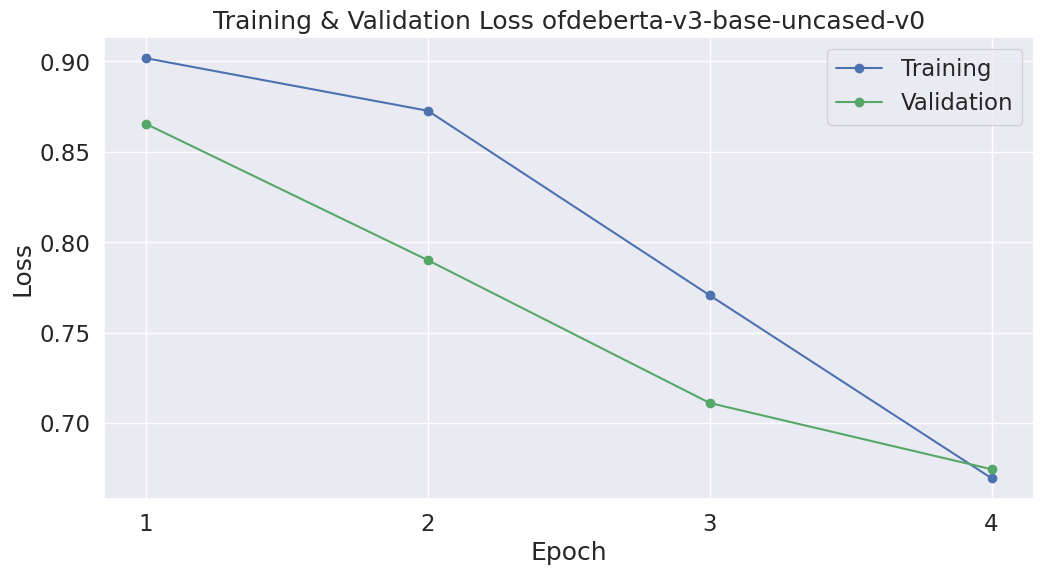

In [39]:
# Plot the learning curves
plot_training_stats(df_stats, "deberta-v3-base-uncased-v0")

In [40]:
# Get predictions from the last epoch (v0 has no early stopping, so last epoch = final model)
all_preds = training_stats[-1]["preds"]
all_labels = training_stats[-1]["labels"]

In [41]:
# Inspect a sample prediction
print(f"True label: {all_labels[0]}, {id2label[all_labels[0]]}")
print(f"Predicted: {all_preds[0]}, {id2label[all_preds[0]]}")

True label: 1, Ambivalent
Predicted: 1, Ambivalent


In [42]:
# Classification report
print(classification_report(all_labels, all_preds, target_names=["Clear Reply", "Ambivalent", "Clear Non-Reply"]))

                 precision    recall  f1-score   support

    Clear Reply       0.59      0.40      0.47       151
     Ambivalent       0.71      0.82      0.76       305
Clear Non-Reply       0.67      0.72      0.69        53

       accuracy                           0.68       509
      macro avg       0.66      0.64      0.64       509
   weighted avg       0.67      0.68      0.67       509



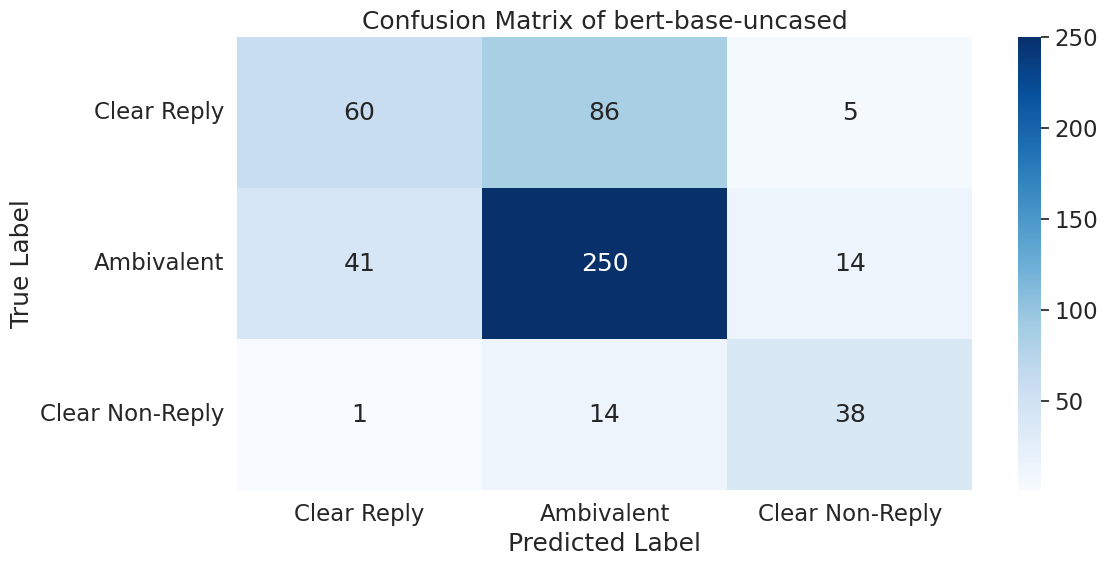

In [43]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Clear Reply", "Ambivalent", "Clear Non-Reply"],
            yticklabels=["Clear Reply", "Ambivalent", "Clear Non-Reply"])
plt.title("Confusion Matrix of bert-base-uncased")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("confusion-matrix-deberta-v3-base-uncased-v0.png", dpi=150, bbox_inches="tight")
plt.show()

In [44]:
# Save baseline results
results = []

results.append({
    "model": "deberta-v3-base-v0",
    "description": "baseline",
    "lr": 2e-5,
    "bs": 16,
    "max_len": 512,
    "epochs": 4,
    "best_epoch": 4,
    "warmup": 0.0,
    "wd": 0.0,
    "w_loss": False,
    "input_form": "text_pair",
    "macro_f1": f1_score(all_labels, all_preds, average="macro"),
    "weighted_f1": f1_score(all_labels, all_preds, average="weighted")
})

In [45]:
# Display only the columns that change across versions
cols_to_show = ["model", "description", "lr", "wd", "w_loss", "warmup", "input_form", "best_epoch", "macro_f1", "weighted_f1"]
display(pd.DataFrame(results)[cols_to_show].style.hide(axis="index"))

model,description,lr,wd,w_loss,warmup,input_form,best_epoch,macro_f1,weighted_f1
deberta-v3-base-v0,baseline,0.000020,0.000000,False,0.000000,text_pair,4,0.642859,0.670065


## Experiments

In this section, we systematically improve macro F1 through a series of controlled experiments: class weighting to handle class imbalance, hyperparameter tuning, warmup scheduling, and input formulation comparison. Each experiment isolates one variable at a time, and the best settings found are combined in a final retrain.

### Helper Functions

In [30]:
def tokenize_data(questions, answers, tokenizer, max_length, input_formulation):
  """
  Tokenizes question-answer pairs using the AutoTokenizer.

  Args:
      questions: numpy array of question strings
      answers: numpy array of answer strings
      tokenizer: AutoTokenizer instance
      max_length: maximum token length (padding & truncation)
      input_formulation: 'text_pair' for pair encoding or 'concat' for manual [SEP] concatenation

  Returns:
      input_ids, attention_masks, token_type_ids (or None if not available)
  """
  input_ids = []
  attention_masks = []
  token_type_ids = []

  for i in range(len(questions)):
    if input_formulation == "text_pair":
      encoded_dict = tokenizer.encode_plus(
          questions[i],
          answers[i],
          add_special_tokens=True,
          max_length=max_length,
          padding="max_length",
          truncation=True,
          return_attention_mask=True,
          return_tensors="pt",
    )
    else:
      sent = questions[i] + " [SEP] " + answers[i]
      encoded_dict = tokenizer.encode_plus(
          sent,
          add_special_tokens=True,
          max_length=max_length,
          padding="max_length",
          truncation=True,
          return_attention_mask=True,
          return_tensors="pt",
    )
    input_ids.append(encoded_dict["input_ids"])
    attention_masks.append(encoded_dict["attention_mask"])
    if "token_type_ids" in encoded_dict:
      token_type_ids.append(encoded_dict["token_type_ids"])

  input_ids = torch.cat(input_ids, dim=0)
  attention_masks = torch.cat(attention_masks, dim=0)

  if len(token_type_ids) > 0:
    token_type_ids = torch.cat(token_type_ids, dim=0)
    return input_ids, attention_masks, token_type_ids
  else:
    return input_ids, attention_masks, None

In [31]:
def train_step(model, train_dataloader, optimizer, scheduler, loss_fn, device):
  """
  Performs one full training epoch.

  Args:
      model: AutoModelForSequenceClassification instance
      train_dataloader: DataLoader for training data
      optimizer: AdamW optimizer
      scheduler: learning rate scheduler
      loss_fn: CrossEntropyLoss (weighted or not)
      device: cuda or cpu

  Returns:
      avg_train_loss: average training loss over all batches
  """
  model.train()
  total_train_loss = 0

  for step, batch in enumerate(train_dataloader):
    if len(batch) == 4:
      b_input_ids, b_mask, b_token_type_ids, b_labels = [b.to(device) for b in batch]
    else:
      b_input_ids, b_mask, b_labels = [b.to(device) for b in batch]
      b_token_type_ids = None

    model.zero_grad()

    result = model(b_input_ids,
                   token_type_ids=b_token_type_ids,
                   attention_mask=b_mask,
                   return_dict=True)

    loss = loss_fn(result.logits, b_labels)
    total_train_loss += loss.item()

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    scheduler.step()

  return total_train_loss / len(train_dataloader)


def val_step(model, validation_dataloader, loss_fn, device):
  """
  Performs one full validation epoch.

  Args:
      model: AutoModelForSequenceClassification instance
      validation_dataloader: DataLoader for validation data
      loss_fn: CrossEntropyLoss (weighted or not)
      device: cuda or cpu

  Returns:
      all_preds: list of predicted label ids
      all_labels: list of true label ids
      avg_val_loss: average validation loss
      avg_val_accuracy: average validation accuracy
  """
  model.eval()

  all_preds = []
  all_labels = []
  total_eval_loss = 0
  total_eval_accuracy = 0

  for batch in validation_dataloader:
    if len(batch) == 4:
      b_input_ids, b_mask, b_token_type_ids, b_labels = [b.to(device) for b in batch]
    else:
      b_input_ids, b_mask, b_labels = [b.to(device) for b in batch]
      b_token_type_ids = None

    with torch.no_grad():
      result = model(b_input_ids,
                     token_type_ids=b_token_type_ids,
                     attention_mask=b_mask,
                     return_dict=True)

    loss = loss_fn(result.logits, b_labels)
    total_eval_loss += loss.item()

    logits = result.logits.detach().cpu().numpy()
    label_ids = b_labels.cpu().numpy()

    total_eval_accuracy += flat_accuracy(logits, label_ids)

    preds = np.argmax(logits, axis=1)
    all_preds.extend(preds)
    all_labels.extend(label_ids)

  avg_val_loss = total_eval_loss / len(validation_dataloader)
  avg_val_accuracy = total_eval_accuracy / len(validation_dataloader)

  return all_preds, all_labels, avg_val_loss, avg_val_accuracy

In [32]:
def train_model(model_name, train_df, lr, batch_size, max_length, epochs, warmup_ratio, weight_decay, weighted_loss, input_formulation, train_indices, val_indices, early_stopping, patience):
  """
  Full training pipeline: tokenization, dataset creation, training and validation.

  Args:
      model_name: pretrained model name (e.g., 'distilbert-base-uncased')
      train_df: training dataframe with 'question', 'interview_answer', 'label' columns
      lr: learning rate
      batch_size: batch size for training and validation
      max_length: maximum token length
      epochs: number of training epochs
      warmup_ratio: fraction of total steps used for warmup
      weight_decay: L2 regularization strength
      weighted_loss: whether to use class-weighted CrossEntropyLoss
      input_formulation: 'text_pair' or 'concat'
      train_indices: pre-saved train indices from BERT notebook for fair comparison
      val_indices: pre-saved val indices from BERT notebook for fair comparison
      early_stopping: whether to stop training early if val loss doesn't improve
      patience: number of epochs to wait before stopping

  Returns:
      model: trained model
      training_stats: list of dicts with per-epoch metrics
      all_preds: final epoch validation predictions
      all_labels: final epoch validation true labels
      best_epoch: epoch at which the best model was found
  """
  # Tokenize
  questions = train_df["question"].values
  answers = train_df["interview_answer"].values
  labels = train_df["label"].values

  input_ids, attention_masks, token_type_ids = tokenize_data(questions, answers, tokenizer, max_length, input_formulation)
  labels_tensor = torch.tensor(labels)

  # Build TensorDataset
  if token_type_ids is not None:
    dataset = TensorDataset(input_ids, attention_masks, token_type_ids, labels_tensor)
  else:
    dataset = TensorDataset(input_ids, attention_masks, labels_tensor)

  # Use pre-saved indices from BERT notebook for fair comparison
  train_dataset = torch.utils.data.Subset(dataset, train_indices)
  val_dataset = torch.utils.data.Subset(dataset, val_indices)

  # DataLoaders
  train_dataloader = DataLoader(train_dataset, sampler=RandomSampler(train_dataset), batch_size=batch_size)
  validation_dataloader = DataLoader(val_dataset, sampler=SequentialSampler(val_dataset), batch_size=batch_size)

  # Model
  model = AutoModelForSequenceClassification.from_pretrained(
      model_name,
      num_labels=3,
      output_attentions=False,
      output_hidden_states=False,
      use_safetensors=True,
  )
  model.to(device)

  # Loss
  if weighted_loss:
    class_weights = compute_class_weight('balanced', classes=np.array([0,1,2]), y=labels)
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor)
  else:
    loss_fn = nn.CrossEntropyLoss()

  # Optimizer & Scheduler
  optimizer = AdamW(model.parameters(), lr=lr, eps=1e-8, weight_decay=weight_decay)
  total_steps = len(train_dataloader) * epochs
  warmup_steps = int(total_steps * warmup_ratio)
  scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

  training_stats = []
  best_val_loss = float("inf")
  best_model_state = None
  epochs_no_improve = 0
  best_epoch = 1

  # Training loop
  total_t0 = time.time()
  for epoch_i in range(epochs):
    print(f"\n======== Epoch {epoch_i+1} / {epochs} ========")

    t0 = time.time()
    avg_train_loss = train_step(model, train_dataloader, optimizer, scheduler, loss_fn, device)
    training_time = time.time() - t0

    t1 = time.time()
    all_preds, all_labels, avg_val_loss, avg_val_accuracy = val_step(model, validation_dataloader, loss_fn, device)
    validation_time = time.time() - t1

    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    weighted_f1 = f1_score(all_labels, all_preds, average="weighted")

    print(f"  Train Loss: {avg_train_loss:.2f} | Val Loss: {avg_val_loss:.2f} | Gap: {avg_val_loss - avg_train_loss:.2f} | Macro F1: {macro_f1:.2f}")

    training_stats.append({
        "epoch": epoch_i + 1,
        "Train Loss": avg_train_loss,
        "Val Loss": avg_val_loss,
        "Generalization Gap": avg_val_loss - avg_train_loss,
        "Val Acc": avg_val_accuracy,
        "Val Macro F1": macro_f1,
        "Val Weighted F1": weighted_f1,
        "Training Time": training_time,
        "Validation Time": validation_time
    })

    # Early stopping
    if early_stopping:
      if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
        best_epoch = epoch_i + 1
      else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
          print(f"  Early stopping triggered at epoch: {epoch_i + 1}. Best model restored from epoch: {best_epoch}")
          break

  # Restore best model
  if early_stopping and best_model_state is not None:
    model.load_state_dict(best_model_state)
    model.to(device)

  print("Total training took {:}".format(format_time(time.time() - total_t0)))

  return model, training_stats, all_preds, all_labels, best_epoch

### Default Configuration

In [33]:
# Default hyperparameters for all experiments
MODEL_NAME = "microsoft/deberta-v3-base"
LR = 2e-5
BATCH_SIZE = 16
MAX_LENGTH = 512
EPOCHS = 6
WARMUP_RATIO = 0.0
WEIGHT_DECAY = 0.0
WEIGHTED_LOSS = False
INPUT_FORMULATION = "text_pair"
EARLY_STOPPING = True
PATIENCE = 2

### Class Imbalance Handling

In [50]:
# Run training loop with class weighting
model_v1, stats_v1, preds_v1, labels_v1, be = train_model(
    model_name=MODEL_NAME,
    train_df=train_df,
    lr=LR,
    batch_size=BATCH_SIZE,
    max_length=MAX_LENGTH,
    epochs=EPOCHS,
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    weighted_loss=True,
    input_formulation=INPUT_FORMULATION,
    train_indices=train_indices,
    val_indices=val_indices,
    early_stopping=False,
    patience=PATIENCE
)

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



======== Epoch 1 / 6 ========
  Train Loss: 1.04 | Val Loss: 0.82 | Gap: -0.22 | Macro F1: 0.46

======== Epoch 2 / 6 ========
  Train Loss: 0.90 | Val Loss: 0.82 | Gap: -0.07 | Macro F1: 0.59

======== Epoch 3 / 6 ========
  Train Loss: 0.77 | Val Loss: 0.71 | Gap: -0.06 | Macro F1: 0.64

======== Epoch 4 / 6 ========
  Train Loss: 0.63 | Val Loss: 0.84 | Gap: 0.21 | Macro F1: 0.64

======== Epoch 5 / 6 ========
  Train Loss: 0.51 | Val Loss: 0.76 | Gap: 0.26 | Macro F1: 0.64

======== Epoch 6 / 6 ========
  Train Loss: 0.42 | Val Loss: 0.82 | Gap: 0.40 | Macro F1: 0.65
Total training took 0:09:08


In [51]:
# Per-epoch training summary: losses, gap, accuracy, and F1
df_stats_v1 = pd.DataFrame(data=stats_v1).set_index("epoch")
display(df_stats_v1[stats_cols_to_show])

,Train Loss,Val Loss,Generalization Gap,Val Acc,Val Macro F1,Training Time,Validation Time
epoch,,,,,,,
1,1.04,0.82,-0.22,0.50,0.46,86.29,5.05
2,0.90,0.82,-0.07,0.60,0.59,86.26,5.05
3,0.77,0.71,-0.06,0.64,0.64,86.25,5.05
4,0.63,0.84,0.21,0.66,0.64,86.24,5.05
5,0.51,0.76,0.26,0.63,0.64,86.24,5.05
6,0.42,0.82,0.40,0.66,0.65,86.25,5.05


In [52]:
# Save results (v1) and compare with baseline (v0)
results.append({
    "model": "deberta-v3-base-v1",
    "description": "+class weighting",
    "lr": LR,
    "bs": BATCH_SIZE,
    "max_len": MAX_LENGTH,
    "epochs": EPOCHS,
    "best_epoch": 4,
    "warmup": WARMUP_RATIO,
    "wd": WEIGHT_DECAY,
    "w_loss": True,
    "input_form": INPUT_FORMULATION,
    "macro_f1": f1_score(labels_v1, preds_v1, average="macro"),
    "weighted_f1": f1_score(labels_v1, preds_v1, average="weighted")
})

In [58]:
# Display table results of v0 and v1
display(pd.DataFrame(results)[cols_to_show].style.hide(axis="index"))

model,description,lr,wd,w_loss,warmup,input_form,best_epoch,macro_f1,weighted_f1
deberta-v3-base-v0,baseline,0.000020,0.000000,False,0.000000,text_pair,4,0.642859,0.670065
deberta-v3-base-v1,+class weighting,0.000020,0.000000,True,0.000000,text_pair,4,0.657853,0.670739


### Hyperparameter Search

In [59]:
# Hyperparameter grid for search
learning_rates = [3e-5, 2e-5, 1e-5]
batch_sizes = [8, 16]
max_lengths = [512]
weight_decays = [0.0, 0.01]
WEIGHTED_LOSS_SEARCH = True

In [60]:
# # Run hyperparameter search
# hp_results = []

# for lr in learning_rates:
#   for bs in batch_sizes:
#     for ml in max_lengths:
#       for wd in weight_decays:
#         print(f"\n>>> Test lr={lr}, batch_size={bs}, max_length={ml}, weight_decay={wd}\n")

#         _, stats, preds_v2, labels_v2, be = train_model(
#             model_name=MODEL_NAME,
#             train_df=train_df,
#             lr=lr,
#             batch_size=bs,
#             max_length=ml,
#             epochs=EPOCHS,
#             warmup_ratio=WARMUP_RATIO,
#             weight_decay=wd,
#             weighted_loss=WEIGHTED_LOSS_SEARCH,
#             input_formulation=INPUT_FORMULATION,
#             train_indices=train_indices,
#             val_indices=val_indices,
#             early_stopping=EARLY_STOPPING,
#             patience=PATIENCE
#         )

#         hp_results.append({
#             "lr": lr,
#             "batch_size": bs,
#             "max_length": ml,
#             "weight_decay": wd,
#             "best_epoch": be,
#             "macro_f1": f1_score(labels_v2, preds_v2, average="macro"),
#             "weighted_f1": f1_score(labels_v2, preds_v2, average="weighted")
#         })

#         torch.cuda.empty_cache()


>>> Test lr=3e-05, batch_size=8, max_length=512, weight_decay=0.0



Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



======== Epoch 1 / 6 ========
  Train Loss: 1.08 | Val Loss: 1.01 | Gap: -0.07 | Macro F1: 0.37

======== Epoch 2 / 6 ========
  Train Loss: 1.05 | Val Loss: 1.02 | Gap: -0.03 | Macro F1: 0.40

======== Epoch 3 / 6 ========
  Train Loss: 1.05 | Val Loss: 1.01 | Gap: -0.04 | Macro F1: 0.38

======== Epoch 4 / 6 ========
  Train Loss: 1.03 | Val Loss: 0.99 | Gap: -0.04 | Macro F1: 0.48

======== Epoch 5 / 6 ========
  Train Loss: 0.99 | Val Loss: 0.95 | Gap: -0.04 | Macro F1: 0.50

======== Epoch 6 / 6 ========
  Train Loss: 0.96 | Val Loss: 0.96 | Gap: -0.00 | Macro F1: 0.51
Total training took 0:09:49

>>> Test lr=3e-05, batch_size=8, max_length=512, weight_decay=0.01



Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



======== Epoch 1 / 6 ========
  Train Loss: 1.09 | Val Loss: 1.01 | Gap: -0.08 | Macro F1: 0.36

======== Epoch 2 / 6 ========
  Train Loss: 1.10 | Val Loss: 1.10 | Gap: -0.01 | Macro F1: 0.15

======== Epoch 3 / 6 ========
  Train Loss: 1.10 | Val Loss: 1.09 | Gap: -0.01 | Macro F1: 0.25
  Early stopping triggered at epoch: 3. Best model restored from epoch: 1
Total training took 0:04:55

>>> Test lr=3e-05, batch_size=16, max_length=512, weight_decay=0.0



...


======== Epoch 1 / 6 ========
  Train Loss: 1.05 | Val Loss: 0.97 | Gap: -0.08 | Macro F1: 0.33

======== Epoch 2 / 6 ========
  Train Loss: 0.95 | Val Loss: 0.86 | Gap: -0.09 | Macro F1: 0.54

======== Epoch 3 / 6 ========
  Train Loss: 0.81 | Val Loss: 0.78 | Gap: -0.04 | Macro F1: 0.57

======== Epoch 4 / 6 ========
  Train Loss: 0.70 | Val Loss: 0.86 | Gap: 0.16 | Macro F1: 0.57

======== Epoch 5 / 6 ========
  Train Loss: 0.61 | Val Loss: 0.81 | Gap: 0.20 | Macro F1: 0.61
  Early stopping triggered at epoch: 5. Best model restored from epoch: 3
Total training took 0:08:13

>>> Test lr=1e-05, batch_size=16, max_length=512, weight_decay=0.0



Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



======== Epoch 1 / 6 ========
  Train Loss: 1.06 | Val Loss: 0.98 | Gap: -0.08 | Macro F1: 0.37

======== Epoch 2 / 6 ========
  Train Loss: 0.99 | Val Loss: 0.81 | Gap: -0.17 | Macro F1: 0.52

======== Epoch 3 / 6 ========
  Train Loss: 0.85 | Val Loss: 0.89 | Gap: 0.04 | Macro F1: 0.42

======== Epoch 4 / 6 ========
  Train Loss: 0.77 | Val Loss: 0.75 | Gap: -0.02 | Macro F1: 0.54

======== Epoch 5 / 6 ========
  Train Loss: 0.68 | Val Loss: 0.84 | Gap: 0.16 | Macro F1: 0.54

======== Epoch 6 / 6 ========
  Train Loss: 0.64 | Val Loss: 0.80 | Gap: 0.17 | Macro F1: 0.60
  Early stopping triggered at epoch: 6. Best model restored from epoch: 4
Total training took 0:09:10

>>> Test lr=1e-05, batch_size=16, max_length=512, weight_decay=0.01



Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



======== Epoch 1 / 6 ========
  Train Loss: 1.06 | Val Loss: 0.99 | Gap: -0.07 | Macro F1: 0.38

======== Epoch 2 / 6 ========
  Train Loss: 0.98 | Val Loss: 0.81 | Gap: -0.17 | Macro F1: 0.53

======== Epoch 3 / 6 ========
  Train Loss: 0.83 | Val Loss: 0.75 | Gap: -0.09 | Macro F1: 0.60

======== Epoch 4 / 6 ========
  Train Loss: 0.73 | Val Loss: 0.72 | Gap: -0.01 | Macro F1: 0.58

======== Epoch 5 / 6 ========
  Train Loss: 0.65 | Val Loss: 0.77 | Gap: 0.12 | Macro F1: 0.62

======== Epoch 6 / 6 ========
  Train Loss: 0.61 | Val Loss: 0.74 | Gap: 0.14 | Macro F1: 0.61
  Early stopping triggered at epoch: 6. Best model restored from epoch: 4
Total training took 0:09:11


In [61]:
# Results from hyperparameter search, sorted by macro F1 (best config on top)
# display(pd.DataFrame(hp_results).sort_values("macro_f1", ascending=False))

,lr,batch_size,max_length,weight_decay,best_epoch,macro_f1,weighted_f1
6,2.00e-05,16,512,0.00,3,0.67,0.69
8,1.00e-05,8,512,0.00,3,0.66,0.69
3,3.00e-05,16,512,0.01,3,0.66,0.67
5,2.00e-05,8,512,0.01,3,0.66,0.67
2,3.00e-05,16,512,0.00,4,0.65,0.67
4,2.00e-05,8,512,0.00,2,0.63,0.67
7,2.00e-05,16,512,0.01,2,0.62,0.61
11,1.00e-05,16,512,0.01,4,0.61,0.62
9,1.00e-05,8,512,0.01,3,0.61,0.63
10,1.00e-05,16,512,0.00,4,0.60,0.58


In [63]:
# HP search results hardcoded to avoid re-running (for Kaggle's competition)
hp_results = [
    {"lr": 2e-5, "batch_size": 16, "max_length": 512, "weight_decay": 0.00, "best_epoch": 3, "macro_f1": 0.67, "weighted_f1": 0.69},
    {"lr": 1e-5, "batch_size": 8,  "max_length": 512, "weight_decay": 0.00, "best_epoch": 3, "macro_f1": 0.66, "weighted_f1": 0.69},
    {"lr": 3e-5, "batch_size": 16, "max_length": 512, "weight_decay": 0.01, "best_epoch": 3, "macro_f1": 0.66, "weighted_f1": 0.67},
    {"lr": 2e-5, "batch_size": 8,  "max_length": 512, "weight_decay": 0.01, "best_epoch": 3, "macro_f1": 0.66, "weighted_f1": 0.67},
    {"lr": 3e-5, "batch_size": 16, "max_length": 512, "weight_decay": 0.00, "best_epoch": 4, "macro_f1": 0.65, "weighted_f1": 0.67},
    {"lr": 2e-5, "batch_size": 8,  "max_length": 512, "weight_decay": 0.00, "best_epoch": 2, "macro_f1": 0.63, "weighted_f1": 0.67},
    {"lr": 2e-5, "batch_size": 16, "max_length": 512, "weight_decay": 0.01, "best_epoch": 2, "macro_f1": 0.62, "weighted_f1": 0.61},
    {"lr": 1e-5, "batch_size": 16, "max_length": 512, "weight_decay": 0.01, "best_epoch": 4, "macro_f1": 0.61, "weighted_f1": 0.62},
    {"lr": 1e-5, "batch_size": 8,  "max_length": 512, "weight_decay": 0.01, "best_epoch": 3, "macro_f1": 0.61, "weighted_f1": 0.63},
    {"lr": 1e-5, "batch_size": 16, "max_length": 512, "weight_decay": 0.00, "best_epoch": 4, "macro_f1": 0.60, "weighted_f1": 0.58},
    {"lr": 3e-5, "batch_size": 8,  "max_length": 512, "weight_decay": 0.00, "best_epoch": 5, "macro_f1": 0.51, "weighted_f1": 0.56},
    {"lr": 3e-5, "batch_size": 8,  "max_length": 512, "weight_decay": 0.01, "best_epoch": 1, "macro_f1": 0.25, "weighted_f1": 0.45},
]

# Results from hyperparameter search, sorted by macro F1
display(pd.DataFrame(hp_results).sort_values("macro_f1", ascending=False))

,lr,batch_size,max_length,weight_decay,best_epoch,macro_f1,weighted_f1
0,2.00e-05,16,512,0.00,3,0.67,0.69
1,1.00e-05,8,512,0.00,3,0.66,0.69
2,3.00e-05,16,512,0.01,3,0.66,0.67
3,2.00e-05,8,512,0.01,3,0.66,0.67
4,3.00e-05,16,512,0.00,4,0.65,0.67
5,2.00e-05,8,512,0.00,2,0.63,0.67
6,2.00e-05,16,512,0.01,2,0.62,0.61
7,1.00e-05,16,512,0.01,4,0.61,0.62
8,1.00e-05,8,512,0.01,3,0.61,0.63
9,1.00e-05,16,512,0.00,4,0.60,0.58


In [64]:
# Save best hyperparameter config to general results list (we keep excluding batch size from results as is same everywhere, despite all trials with 8)
best_hp = pd.DataFrame(hp_results).sort_values("macro_f1", ascending=False).iloc[0]

results.append({
    "model": "deberta-v3-base-v2",
    "description": "+hyperparameter search",
    "lr": best_hp["lr"],
    "bs": int(best_hp["batch_size"]),
    "max_len": int(best_hp["max_length"]),
    "epochs": EPOCHS,
    "best_epoch": best_hp["best_epoch"],
    "warmup": WARMUP_RATIO,
    "wd": best_hp["weight_decay"],
    "w_loss": WEIGHTED_LOSS_SEARCH,
    "input_form": INPUT_FORMULATION,
    "macro_f1": best_hp["macro_f1"],
    "weighted_f1": best_hp["weighted_f1"]
})

In [65]:
# Display table results of v0, v1, v2
display(pd.DataFrame(results)[cols_to_show].style.hide(axis="index"))

model,description,lr,wd,w_loss,warmup,input_form,best_epoch,macro_f1,weighted_f1
deberta-v3-base-v0,baseline,0.000020,0.000000,False,0.000000,text_pair,4.000000,0.642859,0.670065
deberta-v3-base-v1,+class weighting,0.000020,0.000000,True,0.000000,text_pair,4.000000,0.657853,0.670739
deberta-v3-base-v2,+hyperparameter search,0.000020,0.000000,True,0.000000,text_pair,3.000000,0.670000,0.690000


### Warmup Steps

In [74]:
# # Test effect of warmup ratio using best config from v2
# warmup_ratios = [0.0, 0.1]
# warmup_results = []

# for wr in warmup_ratios:
#   print(f"\n>>> Test warmup_ratio={wr}\n")

#   _, stats, preds, labels_val, be = train_model(
#       model_name=MODEL_NAME,
#       train_df=train_df,
#       lr=best_hp["lr"],
#       batch_size=int(best_hp["batch_size"]),
#       max_length=int(best_hp["max_length"]),
#       epochs=EPOCHS,
#       warmup_ratio=wr,
#       weight_decay=best_hp["weight_decay"],
#       weighted_loss=WEIGHTED_LOSS_SEARCH,
#       input_formulation=INPUT_FORMULATION,
#       train_indices=train_indices,
#       val_indices=val_indices,
#       early_stopping=EARLY_STOPPING,
#       patience=PATIENCE
#   )

#   warmup_results.append({
#       "warmup_ratio": wr,
#       "best_epoch": be,
#       "macro_f1": f1_score(labels_val, preds, average="macro"),
#       "weighted_f1": f1_score(labels_val, preds, average="weighted")
#   })

#   torch.cuda.empty_cache()


>>> Test warmup_ratio=0.0



Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



======== Epoch 1 / 6 ========
  Train Loss: 1.03 | Val Loss: 0.85 | Gap: -0.18 | Macro F1: 0.54

======== Epoch 2 / 6 ========
  Train Loss: 0.85 | Val Loss: 0.78 | Gap: -0.07 | Macro F1: 0.62

======== Epoch 3 / 6 ========
  Train Loss: 0.72 | Val Loss: 0.69 | Gap: -0.02 | Macro F1: 0.65

======== Epoch 4 / 6 ========
  Train Loss: 0.61 | Val Loss: 0.72 | Gap: 0.11 | Macro F1: 0.65

======== Epoch 5 / 6 ========
  Train Loss: 0.48 | Val Loss: 0.75 | Gap: 0.26 | Macro F1: 0.66
  Early stopping triggered at epoch: 5. Best model restored from epoch: 3
Total training took 0:07:38

>>> Test warmup_ratio=0.1



Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



======== Epoch 1 / 6 ========
  Train Loss: 1.05 | Val Loss: 0.88 | Gap: -0.17 | Macro F1: 0.37

======== Epoch 2 / 6 ========
  Train Loss: 0.86 | Val Loss: 0.74 | Gap: -0.12 | Macro F1: 0.66

======== Epoch 3 / 6 ========
  Train Loss: 0.71 | Val Loss: 0.85 | Gap: 0.14 | Macro F1: 0.61

======== Epoch 4 / 6 ========
  Train Loss: 0.57 | Val Loss: 0.81 | Gap: 0.24 | Macro F1: 0.66
  Early stopping triggered at epoch: 4. Best model restored from epoch: 2
Total training took 0:06:06


In [76]:
# Results from all combos tried, sorted by macro F1
# display(pd.DataFrame(warmup_results).sort_values("macro_f1", ascending=False))

,warmup_ratio,best_epoch,macro_f1,weighted_f1
1,0.1,2,0.66,0.68
0,0.0,3,0.66,0.68


In [34]:
# Warmup results hardcoded to avoid re-running (for Kaggle's competition)
warmup_results = [
    {"warmup_ratio": 0.1, "best_epoch": 2, "macro_f1": 0.66, "weighted_f1": 0.68},
    {"warmup_ratio": 0.0, "best_epoch": 3, "macro_f1": 0.66, "weighted_f1": 0.68},
]

In [35]:
# Save best warmup
best_warmup = pd.DataFrame(warmup_results).sort_values("macro_f1", ascending=False).iloc[0]

In [89]:
# # Save best config to results
# results.append({
#     "model": "deberta-v3-base-v3",
#     "description": "+warmup",
#     "lr": best_hp["lr"],
#     "bs": int(best_hp["batch_size"]),
#     "max_len": int(best_hp["max_length"]),
#     "epochs": EPOCHS,
#     "best_epoch": best_warmup["best_epoch"],
#     "warmup": best_warmup["warmup_ratio"],
#     "wd": best_hp["weight_decay"],
#     "w_loss": WEIGHTED_LOSS_SEARCH,
#     "input_form": INPUT_FORMULATION,
#     "macro_f1": best_warmup["macro_f1"],
#     "weighted_f1": best_warmup["weighted_f1"]
# })

# Display table results of v0, v1, v2, v3
# display(pd.DataFrame(results)[cols_to_show].style.hide(axis="index"))

### Input Formulation

In [96]:
# # Test effect of input formulation using best config from v3
# formulations = ["text_pair", "concat"]
# formulation_results = []

# for formulation in formulations:
#   print(f"\n>>> Test input_formulation={formulation}\n")

#   _, stats, preds, labels_val, be = train_model(
#       model_name=MODEL_NAME,
#       train_df=train_df,
#       lr=best_hp["lr"],
#       batch_size=int(best_hp["batch_size"]),
#       max_length=int(best_hp["max_length"]),
#       epochs=EPOCHS,
#       warmup_ratio=best_warmup["warmup_ratio"],
#       weight_decay=best_hp["weight_decay"],
#       weighted_loss=WEIGHTED_LOSS_SEARCH,
#       input_formulation=formulation,
#       train_indices=train_indices,
#       val_indices=val_indices,
#       early_stopping=EARLY_STOPPING,
#       patience=PATIENCE
#   )

#   formulation_results.append({
#       "input_formulation": formulation,
#       "best_epoch": be,
#       "macro_f1": f1_score(labels_val, preds, average="macro"),
#       "weighted_f1": f1_score(labels_val, preds, average="weighted")
#   })

#   torch.cuda.empty_cache()


>>> Test input_formulation=text_pair



Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



======== Epoch 1 / 6 ========
  Train Loss: 1.06 | Val Loss: 0.95 | Gap: -0.11 | Macro F1: 0.40

======== Epoch 2 / 6 ========
  Train Loss: 0.94 | Val Loss: 0.75 | Gap: -0.20 | Macro F1: 0.62

======== Epoch 3 / 6 ========
  Train Loss: 0.76 | Val Loss: 0.71 | Gap: -0.06 | Macro F1: 0.59

======== Epoch 4 / 6 ========
  Train Loss: 0.61 | Val Loss: 0.67 | Gap: 0.06 | Macro F1: 0.65

======== Epoch 5 / 6 ========
  Train Loss: 0.47 | Val Loss: 0.71 | Gap: 0.24 | Macro F1: 0.66

======== Epoch 6 / 6 ========
  Train Loss: 0.35 | Val Loss: 0.78 | Gap: 0.42 | Macro F1: 0.64
  Early stopping triggered at epoch: 6. Best model restored from epoch: 4
Total training took 0:09:10

>>> Test input_formulation=concat



Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



======== Epoch 1 / 6 ========
  Train Loss: 1.07 | Val Loss: 0.94 | Gap: -0.12 | Macro F1: 0.38

======== Epoch 2 / 6 ========
  Train Loss: 0.92 | Val Loss: 0.71 | Gap: -0.22 | Macro F1: 0.62

======== Epoch 3 / 6 ========
  Train Loss: 0.76 | Val Loss: 0.71 | Gap: -0.05 | Macro F1: 0.64

======== Epoch 4 / 6 ========
  Train Loss: 0.63 | Val Loss: 0.71 | Gap: 0.07 | Macro F1: 0.66
  Early stopping triggered at epoch: 4. Best model restored from epoch: 2
Total training took 0:06:06


In [97]:
# Results from all combos tried, sorted by macro F1
# display(pd.DataFrame(formulation_results).sort_values("macro_f1", ascending=False))

,input_formulation,best_epoch,macro_f1,weighted_f1
1,concat,2,0.66,0.68
0,text_pair,4,0.64,0.65


In [36]:
# Input formulation results hardcoded to avoid re-running (for Kaggle's competition)
formulation_results = [
    {"input_formulation": "concat", "best_epoch": 2, "macro_f1": 0.66, "weighted_f1": 0.68},
    {"input_formulation": "text_pair", "best_epoch": 4, "macro_f1": 0.64, "weighted_f1": 0.65},
]
display(pd.DataFrame(formulation_results).sort_values("macro_f1", ascending=False))

,input_formulation,best_epoch,macro_f1,weighted_f1
0,concat,2,0.66,0.68
1,text_pair,4,0.64,0.65


In [37]:
# Save best formulation
best_formulation = pd.DataFrame(formulation_results).sort_values("macro_f1", ascending=False).iloc[0]

### Best Configuration & Final Retraining

Throughout the experiments, we systematically isolated the effect of class weighting, hyperparameter tuning, warmup ratio application, and input formulation on macro F1, reinitializing the model from scratch at each step. To obtain the best possible performance, we now retrain a single model combining all the best settings found across experiments.

In [101]:
# Display all results sorted by macro F1
results_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)
display(results_df)

,model,description,lr,bs,max_len,epochs,best_epoch,warmup,wd,w_loss,input_form,macro_f1,weighted_f1
2,deberta-v3-base-v2,+hyperparameter search,2.00e-05,16,512,6,3.0,0.0,0.0,True,text_pair,0.67,0.69
1,deberta-v3-base-v1,+class weighting,2.00e-05,16,512,6,4.0,0.0,0.0,True,text_pair,0.66,0.67
0,deberta-v3-base-v0,baseline,2.00e-05,16,512,4,4.0,0.0,0.0,False,text_pair,0.64,0.67


In [103]:
# Best overall configuration (without best warmup and input formulation)
best_config = results_df.iloc[0]
# display(best_config)

In [105]:
# Retrain with best configuration (with best warmup and input formulation)
best_model, best_stats, best_preds, best_labels, best_epoch = train_model(
    model_name=MODEL_NAME,
    train_df=train_df,
    lr=best_config["lr"],
    batch_size=int(best_config["bs"]),
    max_length=int(best_config["max_len"]),
    epochs=EPOCHS,
    warmup_ratio=best_warmup["warmup_ratio"],
    weight_decay=best_config["wd"],
    weighted_loss=best_config["w_loss"],
    input_formulation=best_formulation["input_formulation"],
    train_indices=train_indices,
    val_indices=val_indices,
    early_stopping=EARLY_STOPPING,
    patience=PATIENCE
)

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



======== Epoch 1 / 6 ========
  Train Loss: 1.05 | Val Loss: 0.90 | Gap: -0.16 | Macro F1: 0.32

======== Epoch 2 / 6 ========
  Train Loss: 0.87 | Val Loss: 0.73 | Gap: -0.14 | Macro F1: 0.61

======== Epoch 3 / 6 ========
  Train Loss: 0.74 | Val Loss: 0.75 | Gap: 0.01 | Macro F1: 0.61

======== Epoch 4 / 6 ========
  Train Loss: 0.63 | Val Loss: 0.71 | Gap: 0.07 | Macro F1: 0.69

======== Epoch 5 / 6 ========
  Train Loss: 0.49 | Val Loss: 0.72 | Gap: 0.23 | Macro F1: 0.68

======== Epoch 6 / 6 ========
  Train Loss: 0.41 | Val Loss: 0.75 | Gap: 0.34 | Macro F1: 0.67
  Early stopping triggered at epoch: 6. Best model restored from epoch: 4
Total training took 0:09:10


In [106]:
# Per-epoch training summary: losses, gap, accuracy, and F1
df_best_stats = pd.DataFrame(best_stats).set_index("epoch")
display(df_best_stats[stats_cols_to_show])

,Train Loss,Val Loss,Generalization Gap,Val Acc,Val Macro F1,Training Time,Validation Time
epoch,,,,,,,
1,1.05,0.90,-0.16,0.33,0.32,86.36,5.05
2,0.87,0.73,-0.14,0.59,0.61,86.30,5.05
3,0.74,0.75,0.01,0.67,0.61,86.30,5.05
4,0.63,0.71,0.07,0.69,0.69,86.30,5.05
5,0.49,0.72,0.23,0.69,0.68,86.30,5.05
6,0.41,0.75,0.34,0.66,0.67,86.30,5.05


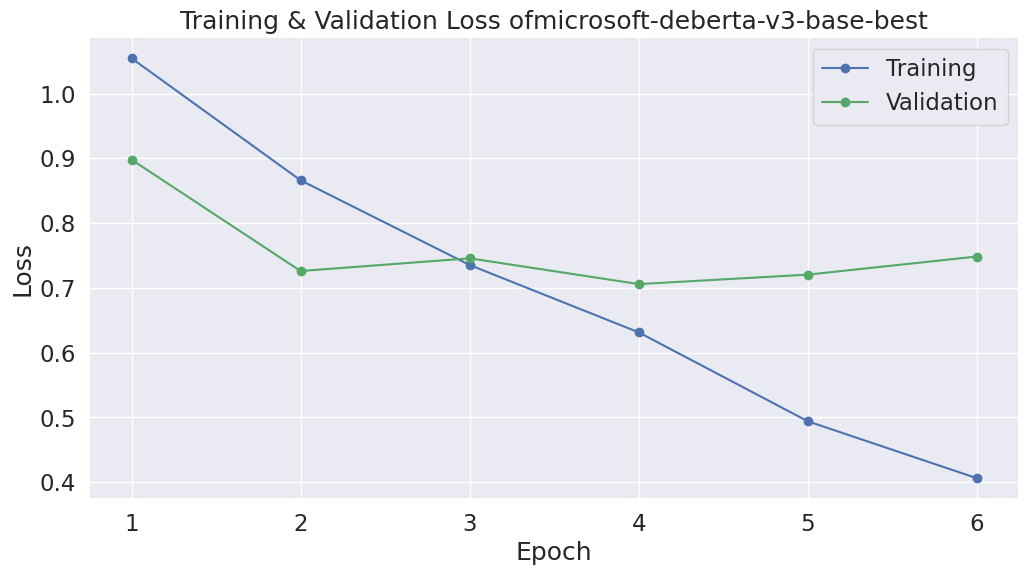

In [107]:
# Learning curves
plot_training_stats(df_best_stats, "microsoft-deberta-v3-base-best")

In [108]:
# Classification report
print(classification_report(best_labels, best_preds, target_names=["Clear Reply", "Ambivalent", "Clear Non-Reply"]))

                 precision    recall  f1-score   support

    Clear Reply       0.51      0.72      0.60       151
     Ambivalent       0.79      0.61      0.69       305
Clear Non-Reply       0.69      0.75      0.72        53

       accuracy                           0.66       509
      macro avg       0.66      0.70      0.67       509
   weighted avg       0.69      0.66      0.67       509



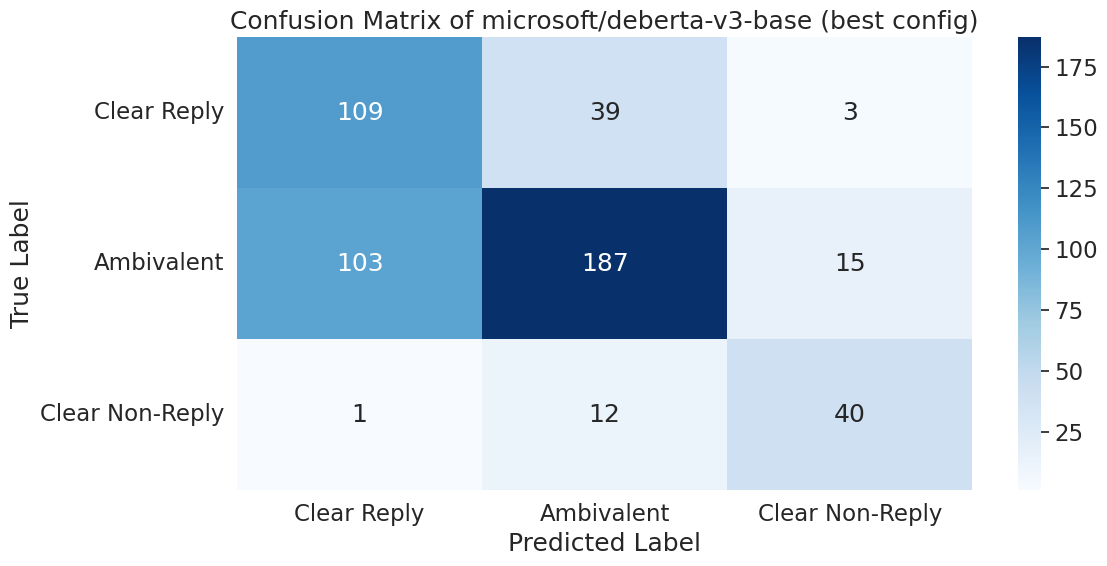

In [109]:
# Confusion matrix
cm = confusion_matrix(best_labels, best_preds)
plt.figure(figsize=(12, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Clear Reply", "Ambivalent", "Clear Non-Reply"],
            yticklabels=["Clear Reply", "Ambivalent", "Clear Non-Reply"])
plt.title("Confusion Matrix of microsoft/deberta-v3-base (best config)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("confusion-matrix-deberta-best.png", dpi=150, bbox_inches="tight")
plt.show()

In [111]:
# Some extra metrics from final retrain
best_total_params = sum(p.numel() for p in best_model.parameters())
best_total_training_time = round(sum(s["Training Time"] for s in best_stats), 2)
best_avg_inference_time = round((best_stats[best_epoch-1]["Validation Time"] / len(val_indices)) * 1000, 2)
best_gen_gap = round(best_stats[best_epoch-1]["Generalization Gap"], 2)
best_vocab_size = tokenizer.vocab_size

print(f"vocab_size: {best_vocab_size}")
print(f"total_params: {best_total_params}")
print(f"total_training_time: {best_total_training_time}")
print(f"avg_inference_time: {best_avg_inference_time}")
print(f"gen_gap: {best_gen_gap}")

vocab_size: 128000
total_params: 184424451
total_training_time: 517.86
avg_inference_time: 9.92
gen_gap: 0.07


In [116]:
# Save final retrain results and display full experiment summary
results.append({
    "model": "deberta-v3-base-best",
    "description": "final retrain",
    "lr": best_config["lr"],
    "bs": int(best_config["bs"]),
    "max_len": int(best_config["max_len"]),
    "epochs": int(best_config["best_epoch"]),
    "best_epoch": int(best_epoch),
    "warmup": best_warmup["warmup_ratio"],
    "wd": best_config["wd"],
    "w_loss": best_config["w_loss"],
    "input_form": best_formulation["input_formulation"],
    "macro_f1": f1_score(best_labels, best_preds, average="macro"),
    "weighted_f1": f1_score(best_labels, best_preds, average="weighted")
})

display(pd.DataFrame(results)[cols_to_show].style.hide(axis="index"))

model,description,lr,wd,w_loss,warmup,input_form,best_epoch,macro_f1,weighted_f1
deberta-v3-base-v0,baseline,0.000020,0.000000,False,0.000000,text_pair,4.000000,0.642859,0.670065
deberta-v3-base-v1,+class weighting,0.000020,0.000000,True,0.000000,text_pair,4.000000,0.657853,0.670739
deberta-v3-base-v2,+hyperparameter search,0.000020,0.000000,True,0.000000,text_pair,3.000000,0.670000,0.690000
deberta-v3-base-best,final retrain,0.000020,0.000000,True,0.100000,concat,4.000000,0.669463,0.665434


## Error Analysis

We analyze model errors on the validation set by examining per-class accuracy, sample misclassifications, and error rates across answer length, question length, politician, and interview title groups. Finally, we identify the most common misclassification pairs to understand which class boundaries the model struggles with most.

In [120]:
# Attach predictions to validation dataframe for error analysis
error_df = train_df.iloc[val_indices].copy().reset_index(drop=True)
error_df["predicted"] = [id2label[p] for p in best_preds]
error_df["true_label"] = error_df["clarity_label"]
error_df["correct"] = error_df["predicted"] == error_df["true_label"]

print(f"Total validation samples: {len(error_df)}")
print(f"Correct predictions: {error_df['correct'].sum()}")
print(f"Wrong predictions: {(error_df['correct'] == False).sum()}")

Total validation samples: 509
Correct predictions: 323
Wrong predictions: 186


In [121]:
# Per-class accuracy (same as in classification report)
print("Per-class accuracy:")
for label_name in ["Clear Reply", "Ambivalent", "Clear Non-Reply"]:
  subset = error_df[error_df["true_label"] == label_name]
  acc = subset["correct"].mean()
  print(f" {label_name}: {acc:.2f}% ({subset['correct'].sum()}/{len(subset)})")

Per-class accuracy:
 Clear Reply: 0.60% (91/151)
 Ambivalent: 0.65% (197/305)
 Clear Non-Reply: 0.66% (35/53)


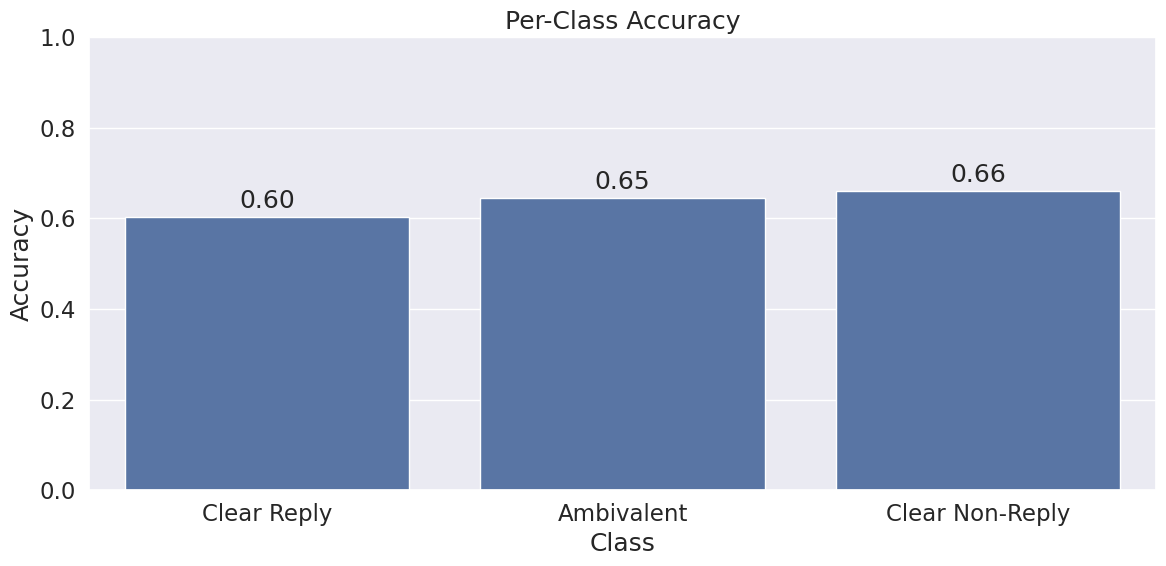

In [122]:
# Bar chart of per-class accuracy
classes = ["Clear Reply", "Ambivalent", "Clear Non-Reply"]
accuracies = [error_df[error_df["true_label"] == c]["correct"].mean() for c in classes]

plt.figure(figsize=(12, 6))
sns.barplot(x=classes, y=accuracies)
plt.title("Per-Class Accuracy")
plt.xlabel("Class")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
for i, v in enumerate(accuracies):
  plt.text(i, v + 0.02, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.savefig("per_class_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

In [123]:
# Show some error examples per class
NUM_EXAMPLES = 3

for label_name in ["Clear Reply", "Ambivalent", "Clear Non-Reply"]:
  print(f"\n=== Errors for true label: {label_name} ===")
  errors = error_df[(error_df["true_label"] == label_name) & (error_df["correct"] == False)]
  for i, row in errors.head(NUM_EXAMPLES).iterrows():
    print(f"\nQuestion: {row['question']}")
    print(f"Answer: {row['interview_answer']}")
    print(f"True: {row['true_label']}  |  Predicted: {row['predicted']}")
    print("-" * 80)


=== Errors for true label: Clear Reply ===

Question: Advice to Democrats who might see the strategy as a path to taking back power that the Republicans employed.
Answer: Well, I'll work in reverse. I think Nancy Pelosi is an outstanding and historic political leader. So much of what we accomplished was accomplished because of her smarts, her tenacity, her legislative skill. And I don't normally meddle with party votes, and certainly on my way out the door, probably, I shouldn't meddle here. But I cannot speak highly enough of Nancy Pelosi. She combines strong, progressive values with just extraordinary political skill. And she does stuff that's tough, not just stuff that's easy. She's done stuff that's unpopular in her own base because it's the right thing to do for the American people. I think she's a remarkable leader.With respect to Democrats and Republicans and how Democrats should deal with a new administration, I think you give them a hearing. I certainly don't want them to do 

In [124]:
# Error rate by answer length: check if model accuracy depends on answer length
error_df["answer_len"] = error_df["interview_answer"].str.split().str.len()

# Divide answers into 4 length groups: Short (<50 words), Medium (50-150), Long (150-300), Very Long (>300)
error_df["answer_len_group"] = pd.cut(error_df["answer_len"],
                                      bins=[0, 50, 150, 300, 2300],
                                      labels=["Short", "Medium", "Long", "Very Long"])


# Calculate and present accuracy and errors per answer length group
summary = error_df.groupby("answer_len_group", observed=True).agg(
    total_samples=("correct", "count"),
    errors=("correct", lambda x: (x == False).sum()),
    accuracy=("correct", "mean")
)

summary["error_rate"] = (summary["errors"] / summary["total_samples"])
display(summary)

,total_samples,errors,accuracy,error_rate
answer_len_group,,,,
Short,116,42,0.64,0.36
Medium,106,41,0.61,0.39
Long,111,47,0.58,0.42
Very Long,176,56,0.68,0.32


In [125]:
# Error rate by question length: check if model accuracy depends on question length
error_df["question_len"] = error_df["question"].str.split().str.len()

# Divide questions into 4 length groups: Short (<10 words), Medium (10-20), Long (20-30), Very Long (>30)
error_df["question_len_group"] = pd.cut(error_df["question_len"],
                                        bins=[0, 10, 20, 30, 100],
                                        labels=["Short", "Medium", "Long", "Very Long"])

# Calculate and present accuracy and errors per question length group
summary_q = error_df.groupby("question_len_group", observed=True).agg(
    total_samples=("correct", "count"),
    errors=("correct", lambda x: (x == False).sum()),
    accuracy=("correct", "mean")
)

summary_q["error_rate"] = (summary_q["errors"] / summary_q["total_samples"])
display(summary_q)

,total_samples,errors,accuracy,error_rate
question_len_group,,,,
Short,196,64,0.67,0.33
Medium,216,89,0.59,0.41
Long,70,27,0.61,0.39
Very Long,27,6,0.78,0.22


In [126]:
# Error rate across politicians
summary_p = error_df.groupby("president", observed=True).agg(
    total_samples=("correct", "count"),
    errors=("correct", lambda x: (x == False).sum()),
    accuracy=("correct", "mean")
)
summary_p["error_rate"] = (summary_p["errors"] / summary_p["total_samples"])
display(summary_p.sort_values("accuracy"))

,total_samples,errors,accuracy,error_rate
president,,,,
Donald J. Trump,219,86,0.61,0.39
George W. Bush,101,39,0.61,0.39
Barack Obama,142,48,0.66,0.34
Joseph R. Biden,47,13,0.72,0.28


In [127]:
# Error rate across interview titles
summary_i = error_df.groupby("title", observed=True).agg(
    total_samples=("correct", "count"),
    errors=("correct", lambda x: (x == False).sum()),
    accuracy=("correct", "mean")
)
summary_i["error_rate"] = (summary_i["errors"] / summary_i["total_samples"])
display(summary_i.sort_values("accuracy")[:5])

,total_samples,errors,accuracy,error_rate
title,,,,
The President's News Conference With President Felipe de Jesus Calderon Hinojosa of Mexico and Prime Minister Stephen Harper of Canada in New Orleans,1,1,0.0,1.0
"The President's News Conference With President Bronislaw Komorowski of Poland in Warsaw, Poland",1,1,0.0,1.0
"The President's News Conference With President Mahmoud Abbas of the Palestinian Authority in Ramallah, Palestinian Territories",1,1,0.0,1.0
The President's News Conference With President Luiz Inacio Lula da Silva of Brazil in Sao Paulo,1,1,0.0,1.0
"The President's News Conference With President Luiz Inacio Lula da Silva of Brazil at Camp David, Maryland",1,1,0.0,1.0


In [128]:
# Most common misclassification pairs
print("Most common misclassification pairs (true → predicted):")
errors = error_df[error_df["correct"] == False]
misclassifications = errors.groupby(["true_label", "predicted"]).size().reset_index(name="count")
misclassifications = misclassifications.sort_values("count", ascending=False)
display(misclassifications)

Most common misclassification pairs (true → predicted):


,true_label,predicted,count
1,Ambivalent,Clear Reply,90
4,Clear Reply,Ambivalent,56
0,Ambivalent,Clear Non-Reply,18
2,Clear Non-Reply,Ambivalent,17
5,Clear Reply,Clear Non-Reply,4
3,Clear Non-Reply,Clear Reply,1


## Performance on Test Set

The following cells evaluate the best trained model on the held-out test set and generate the Kaggle submission file.

### Data Preparation

In [129]:
# Tokenize test set using best configuration
test_questions = test_df["question"].values
test_answers = test_df["interview_answer"].values
test_true_labels = test_df["label"].values

test_input_ids, test_attention_masks, test_token_type_ids = tokenize_data(
    test_questions,
    test_answers,
    tokenizer,
    max_length=int(best_config["max_len"]),
    input_formulation=best_config["input_form"]
)

In [130]:
# Create TensorDataset and Dataloader (no labels for test set)
if test_token_type_ids is not None:
  test_dataset = TensorDataset(test_input_ids, test_attention_masks, test_token_type_ids)
else:
  test_dataset = TensorDataset(test_input_ids, test_attention_masks)

test_dataloader = DataLoader(
    test_dataset,
    sampler=SequentialSampler(test_dataset),
    batch_size=int(best_config["bs"])
)

In [131]:
print(f"Test samples: {len(test_dataset)}")
print(f"Test batches: {len(test_dataloader)}")

Test samples: 308
Test batches: 20


### Evaluate on Test Set

In [132]:
# Generate predictions on test set
print(f"Predicting labels for {len(test_dataset)} test samples...")

# Put model in evaluation mode
best_model.eval()

test_preds = []

for batch in test_dataloader:

  # Add batch to device and unpack the inputs from our dataloader
  if len(batch) == 3:
    b_input_ids, b_mask, b_token_type_ids = [b.to(device) for b in batch]
  else:
    b_input_ids, b_mask = [b.to(device) for b in batch]
    b_token_type_ids = None

  with torch.no_grad():
    # Forward pass, calculate logit predictions
    result = best_model(b_input_ids,
                        token_type_ids=b_token_type_ids,
                        attention_mask=b_mask,
                        return_dict=True)

    logits = result.logits

    # Move logits to CPU
    logits = logits.detach().cpu().numpy()

    # Get predicted class label from logits
    preds = np.argmax(logits, axis=1)

    # Store predictions
    test_preds.extend(preds)

Predicting labels for 308 test samples...


In [133]:
# Inspect a sample prediction
print(f"True label: {test_true_labels[0]}, {id2label[test_true_labels[0]]}")
print(f"Predicted: {test_preds[0]}, {id2label[test_preds[0]]}")

True label: 1, Ambivalent
Predicted: 1, Ambivalent


In [134]:
# Classification report
print(classification_report(test_true_labels, test_preds, target_names=["Clear Reply", "Ambivalent", "Clear Non-Reply"]))

                 precision    recall  f1-score   support

    Clear Reply       0.51      0.32      0.39        79
     Ambivalent       0.76      0.84      0.80       206
Clear Non-Reply       0.45      0.61      0.52        23

       accuracy                           0.69       308
      macro avg       0.57      0.59      0.57       308
   weighted avg       0.67      0.69      0.67       308



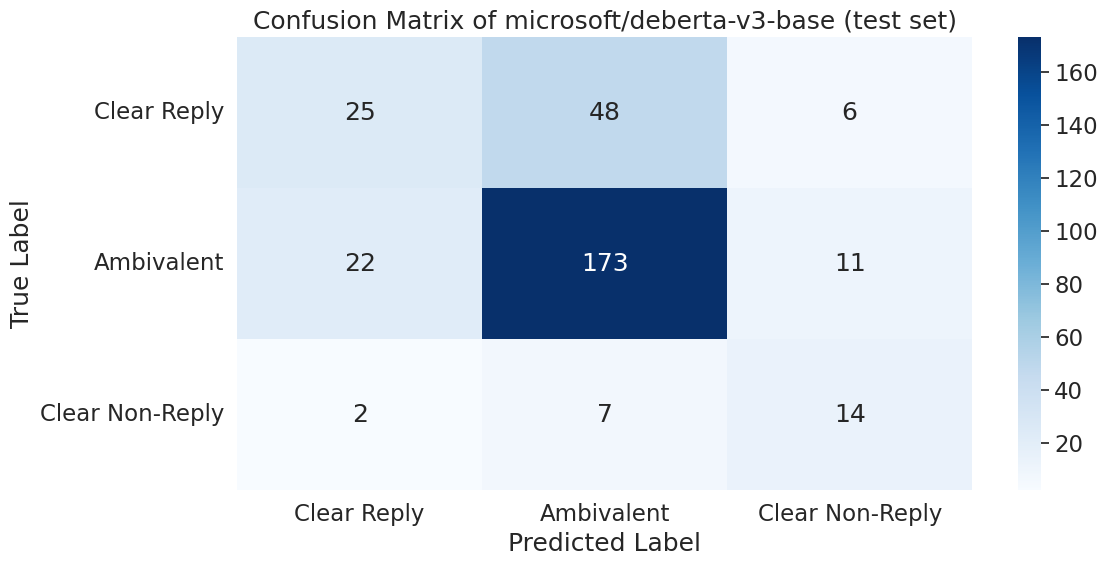

In [135]:
# Confusion matrix
cm = confusion_matrix(test_true_labels, test_preds)
plt.figure(figsize=(12, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Clear Reply", "Ambivalent", "Clear Non-Reply"],
            yticklabels=["Clear Reply", "Ambivalent", "Clear Non-Reply"])
plt.title("Confusion Matrix of microsoft/deberta-v3-base (test set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("confusion-matrix-deberta-test.png", dpi=150, bbox_inches="tight")
plt.show()

### Generate submission.csv

In [136]:
# Save submission CSV
submission = pd.DataFrame({
    "Id": range(len(test_preds)),
    "Predicted": [id2label[p] for p in test_preds]
})

submission.to_csv("submission_microsoft-deberta-v3-base.csv", index=False)

In [137]:
# Display first 3 rows of submission file to verify format
display(submission.head(3))

,Id,Predicted
0,0,Ambivalent
1,1,Ambivalent
2,2,Ambivalent


## Appendix

### Larger model: DeBERTa-v3-Large

In [38]:
# Models to compare
models_list = ["microsoft/deberta-v3-large"]
learning_rates = [1e-5]
batch_sizes = [8]  # bs=16 causes OOM for deberta-v3-large on A100 due to model size
max_lengths = [512]
weight_decays = [0.0, 0.01]
WEIGHTED_LOSS_SEARCH = True

# Check tokenizer vocab size for each model
for model_name in models_list:
  tokenizer = AutoTokenizer.from_pretrained(model_name)
  print(f"{model_name} vocab size: {tokenizer.vocab_size}")

/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:559: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


microsoft/deberta-v3-large vocab size: 128000


In [39]:
# # Run hyperparameter search for larger models
# large_hp_results = []

# for model_name in models_list:
#   for lr in learning_rates:
#     for bs in batch_sizes:
#       for ml in max_lengths:
#         for wd in weight_decays:

#           print(f"\n>>> Model: {model_name}, lr={lr}, batch_size={bs}, max_length={ml}, weight_decay={wd}\n")

#           model, stats, preds, labels_val, be = train_model(
#               model_name=model_name,
#               train_df=train_df,
#               lr=lr,
#               batch_size=bs,
#               max_length=ml,
#               epochs=EPOCHS,
#               warmup_ratio=best_warmup["warmup_ratio"],  # same as above
#               weight_decay=wd,
#               weighted_loss=WEIGHTED_LOSS_SEARCH,  # True
#               input_formulation=best_formulation["input_formulation"],  # same as above
#               train_indices=train_indices,
#               val_indices=val_indices,
#               early_stopping=EARLY_STOPPING,
#               patience=PATIENCE
#           )

#           large_hp_results.append({
#               "model": model_name,
#               "lr": lr,
#               "batch_size": bs,
#               "max_length": ml,
#               "weight_decay": wd,
#               "best_epoch": be,
#               "total_params": sum(p.numel() for p in model.parameters()),
#               "total_training_time": round(sum(s["Training Time"] for s in stats), 2),
#               "avg_inference_time": round((stats[be-1]["Validation Time"] / len(val_indices)) * 1000, 2),
#               "gen_gap": round(stats[be-1]["Generalization Gap"], 2),
#               "macro_f1": f1_score(labels_val, preds, average="macro"),
#               "weighted_f1": f1_score(labels_val, preds, average="weighted")
#           })

#           # Free GPU memory
#           torch.cuda.empty_cache()


>>> Model: microsoft/deberta-v3-large, lr=1e-05, batch_size=8, max_length=512, weight_decay=0.0



Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



======== Epoch 1 / 6 ========
  Train Loss: 1.06 | Val Loss: 0.92 | Gap: -0.14 | Macro F1: 0.56

======== Epoch 2 / 6 ========
  Train Loss: 0.91 | Val Loss: 0.70 | Gap: -0.21 | Macro F1: 0.61

======== Epoch 3 / 6 ========
  Train Loss: 0.72 | Val Loss: 0.72 | Gap: -0.00 | Macro F1: 0.66

======== Epoch 4 / 6 ========
  Train Loss: 0.49 | Val Loss: 1.04 | Gap: 0.55 | Macro F1: 0.69
  Early stopping triggered at epoch: 4. Best model restored from epoch: 2
Total training took 0:19:15

>>> Model: microsoft/deberta-v3-large, lr=1e-05, batch_size=8, max_length=512, weight_decay=0.01



Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



======== Epoch 1 / 6 ========
  Train Loss: 1.05 | Val Loss: 0.83 | Gap: -0.22 | Macro F1: 0.42

======== Epoch 2 / 6 ========
  Train Loss: 0.89 | Val Loss: 0.90 | Gap: 0.01 | Macro F1: 0.58

======== Epoch 3 / 6 ========
  Train Loss: 0.72 | Val Loss: 0.79 | Gap: 0.07 | Macro F1: 0.65

======== Epoch 4 / 6 ========
  Train Loss: 0.52 | Val Loss: 0.82 | Gap: 0.30 | Macro F1: 0.68

======== Epoch 5 / 6 ========
  Train Loss: 0.36 | Val Loss: 1.18 | Gap: 0.81 | Macro F1: 0.69
  Early stopping triggered at epoch: 5. Best model restored from epoch: 3
Total training took 0:24:07


In [40]:
# Results from hyperparameter search, sorted by macro F1 (best config on top)
# display(pd.DataFrame(large_hp_results).sort_values("macro_f1", ascending=False))

,model,lr,batch_size,max_length,weight_decay,best_epoch,total_params,total_training_time,avg_inference_time,gen_gap,macro_f1,weighted_f1
1,microsoft/deberta-v3-large,0.00001,8,512,0.01,3,435064835,1365.34,31.52,0.07,0.694606,0.707079
0,microsoft/deberta-v3-large,0.00001,8,512,0.00,2,435064835,1088.05,31.48,-0.21,0.694350,0.731126


In [ ]:
# HP search results hardcoded to avoid re-running (for Kaggle's competition)
large_hp_results = [
    {"model": "deberta-v3-large", "lr": 1e-5, "batch_size": 8, "max_length": 512, "weight_decay": 0.01, "best_epoch": 3, "total_params": 435064835, "total_training_time": 1365.34, "avg_inference_time": 31.52, "gen_gap": 0.07, "macro_f1": 0.694606, "weighted_f1": 0.707079},
    {"model": "deberta-v3-large", "lr": 1e-5, "batch_size": 8, "max_length": 512, "weight_decay": 0.00, "best_epoch": 2, "total_params": 435064835, "total_training_time": 1088.05, "avg_inference_time": 31.48, "gen_gap": -0.21, "macro_f1": 0.694350, "weighted_f1": 0.731126},
]

# Results from hyperparameter search, sorted by macro F1
display(pd.DataFrame(large_hp_results).sort_values("macro_f1", ascending=False))

In [43]:
# Best large model config
best_large = pd.DataFrame(large_hp_results).sort_values("macro_f1", ascending=False).iloc[0]
# print(best_large)

In [48]:
# Compare best deberta-v3-base vs deberta-v3-large (results hardcoded as models were run in separate sessions due to GPU memory constraints)
base_result = {
    "model": "microsoft/deberta-v3-base",
    "total_params": 184424451,
    "tokenizer_vocab_size": 128000,
    "lr": 2e-5,
    "batch_size": 16,
    "best_epoch": 4,
    "total_training_time": 517.86,
    "avg_inference_time": 9.92,
    "gen_gap": 0.07,
    "macro_f1": 0.669463,
    "weighted_f1": 0.665434,
}

best_large = {
    "model": "microsoft/deberta-v3-large",
    "total_params": 435064835,
    "tokenizer_vocab_size": 128000,
    "lr": 1e-5,
    "batch_size": 8,
    "best_epoch": 3,
    "total_training_time": 1365.34,
    "avg_inference_time": 31.52,
    "gen_gap": 0.07,
    "macro_f1": 0.694606,
    "weighted_f1": 0.707079,
}

cols = ["model", "total_params", "tokenizer_vocab_size", "lr", "batch_size", "best_epoch", "total_training_time", "avg_inference_time", "gen_gap", "macro_f1", "weighted_f1"]
display(pd.DataFrame([base_result, best_large])[cols])

,model,total_params,tokenizer_vocab_size,lr,batch_size,best_epoch,total_training_time,avg_inference_time,gen_gap,macro_f1,weighted_f1
0,microsoft/deberta-v3-base,184424451,128000,0.00002,16,4,517.86,9.92,0.07,0.669463,0.665434
1,microsoft/deberta-v3-large,435064835,128000,0.00001,8,3,1365.34,31.52,0.07,0.694606,0.707079


### Download Figures

In [49]:
# Zip all generated .png figures
import zipfile

with zipfile.ZipFile("figures.zip", "w") as zipf:
  for f in os.listdir("."):
    if f.endswith(".png"):
      zipf.write(f)

In [ ]:
# Download all generated zip files
# from google.colab import files
# files.download("figures.zip")

## References

**Dataset**
- [ailsntua/QEvasion](https://huggingface.co/datasets/ailsntua/QEvasion)

**Papers**
- [DeBERTa paper](https://arxiv.org/abs/2006.03654)
- [DeBERTa-v3 paper](https://arxiv.org/abs/2111.09543)

**HuggingFace Documentation**
- [Tokenizer glossary](https://huggingface.co/transformers/v2.4.0/glossary.html)
- [AutoClass tutorial](https://huggingface.co/docs/transformers/main/en/autoclass_tutorial)
- [encode_plus](https://huggingface.co/docs/transformers/main_classes/tokenizer)
- [microsoft/deberta-v3-base](https://huggingface.co/microsoft/deberta-v3-base)
- [microsoft/deberta-v3-large](https://huggingface.co/microsoft/deberta-v3-large)

**Scikit-learn**
- [compute_class_weight](https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_class_weight.html)

**PyTorch**
- [AdamW optimizer](https://pytorch.org/docs/stable/optim.html)